# Objectif du notebook 

Date de création : 27/10/2025

L'objectif du Notebook est de mettre au propre les résultats de la localisation de la source en mouvement par la méthode RTF-MFP dans le cadre des essais dans le bassin de l'Ifremer. 

L'écriture de ce Notebook intervient après la phase d'étude approfondie des performances des méthodes d'estimations CS / CS-EVD sur les données du bassin. Cette phase d'étude à permis notamment :

* De coder des outils permettant de déterminer les paramètres STFT optimaux pour l'estimation des RTFs dans le bassin.  
* D'identifier et de corriger l'erreur de code conduisant à des résultats incohérents entre la méthode CS et la méthode CS-EVD.   
* De montrer que les performances des estimateurs varient peu en fonction de la durée du signal utilisé suggérant que l'on peut restreindre fortement la durée des segments de signal utilisés pour la localisation de la source en mouvement. 
* D'étudier la distribution de l'angle $\theta$ qui suit, dans le cas des enregistrements en statique, une loi proche d'une loi $\Gamma$. Cette distribution ne s'observe cependant pas dans le cas dynamique et ce même pour un segment correspondant à la position recherchée. Cette analyse suggère que l'utilisation de la moyenne empirique comme grandeur caractéristique de la distribution d'angle n'est pas un choix optimal. L'utilisation de la distribution observée pour construire la densité de probabilité associée et le calcul de l'espérance de la distribution est envisageable et sera étudiée ici bien que cela soit hors du scope du papier JASA El. 
 

In [42]:
import os 
import sys 
import numpy as np 
import xarray as xr
import matplotlib.pyplot as plt  

sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from real_data_analysis.fiberscope_20.src import params
from real_data_analysis.fiberscope_20.src.utils import optimum_stft_params, apply_rtf_mfp
from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager
from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
    FiberscopeSweep1,
)
from propa.rtf.rtf_utils import normalize_metric_contrast, D_hermitian_angle_fast

from publication.publication_figure import color, PubFigure, set_subfigures_abc_labels

pfig = PubFigure()

# Étape 1 : définition des paramètres de l'étude 

## Paramètres généraux 

In [43]:
# Reference hydrophone
h_index_ref = 5  # H5 (assumed to be the receiver with the largest SNR)

rtf_estimators = ["cs", "cs-evd"]

# Static recordings to use
fs_sweep = FiberscopeSweep1()
static_records = fs_sweep.records_N1

# Usefull path
root_data = os.path.join(params.root_data, "localisation", "rtf_mfp")
root_img = os.path.join(
    params.root_img, "localisation", "rtf_mfp"
)

# Folder to store output datasets
root_results = os.path.join(root_data, "results")


# sliced_data_folder = os.path.join(
#     params.root_data, "etude_perf", "duration_influence", "results", "sliced_data"
# )

roots = [
    root_data,
    root_img,
    root_results,
    # sliced_data_folder,
]
for root in roots:
    if not os.path.exists(root):
        os.makedirs(root)

# Fiberscope manager
fsm = FiberscopeManager(
    root_processed_data=root_data,
    h_index_ref=h_index_ref,
    plot_feature=False,
)

# Signal props
data_fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\static\09-10-2024T10-34-58-394627_P1_N1_Sweep_34.nc"
data = xr.open_dataset(data_fpath)
fs = data.fs
ts = 1 / fs

# Idx of the reference receiver
idx_rcv_ref = np.argmin(
    np.abs(data.h_index.values - h_index_ref)
)  # Index of hydrophone might not be sorted or not start at 0

In [44]:
# Define the order based on the source position : from closest to farthest
dict_th_pos = params.dict_th_pos
all_dists = np.array([dict_th_pos[pos] for pos in dict_th_pos.keys()])
idx_pos_sort = np.argsort(all_dists)
src_labels = list(dict_th_pos.keys())
src_label_sorted = [src_labels[i] for i in idx_pos_sort]
all_dists_sorted = all_dists[idx_pos_sort]

In [45]:
# Signal repetition period
Tr = fs_sweep.interp_pulse_period

# Window lengths to use
n_lfm = 1
signal_duration = n_lfm * Tr  # Duration of the snapshot to use in seconds

## Flags
Définition de booléens pour contrôler les cellules à exécuter. Dans le cas où les cellules ne sont pas exécuter l'analyse est faite à partir des résultats précédemment enregistrés. 

In [46]:
run_minimisation = False
plot_minimisation_results = True
run_rtf_mfp = False

# Etape 2 : choix des paramètres STFT $(n_{stft}, \alpha_{ov})$

Cette première étape est essentielle afin d'assurer les performances de la méthode MFP-RTF. 
Pour ce faire, on cherche le couple de paramètres $(n_{stft}, \alpha_{ov})$ qui permet de minimiser la distance à la solution de référence calculée par déconvolution dans le cas des enregistrements statiques. 


## Estimation des paramètres optimaux

In [47]:
# We can choose either to use the empirical mean or compute the statistical expectation derive from the estimated
# underlying probability density function estimated using gaussian kernel density estimation.
theta_statistics = "expectation"        # Take a bit more time but should be more representative of the underlying distribution 
# theta_statistics = "mean"             # Quicker option

if run_minimisation:
    theta_datasets = optimum_stft_params(
        fs_sweep=fs_sweep,
        fsm=fsm,
        fs=fs,
        root_results=root_results,
        signal_duration=signal_duration,
        rtf_estimators=rtf_estimators,
        h_index_ref=h_index_ref,
        idx_rcv_ref=idx_rcv_ref,
        theta_statistics=theta_statistics,
    )
else:
    theta_datasets = {rtf_e: None for rtf_e in rtf_estimators}
    for rtf_e in rtf_estimators:
        # Define the file path to save results
        res_fpath = os.path.join(
            root_results, f"theta_all_static_pos_Tw{signal_duration}_{rtf_e}.nc"
        )

        # Load data
        xr_theta = xr.open_dataset(res_fpath)
        # Store in dict
        theta_datasets[rtf_e] = xr_theta

## Affichage des résultats pour le choix du couple de paramètres optimaux 

In [48]:
# Compute usefull quantities
theta_all_pos = {rtf_e: theta_datasets[rtf_e].theta.values for rtf_e in rtf_estimators}
theta_mean_over_pos = {rtf_e: theta_datasets[rtf_e].theta.mean(dim="pos_id").values for rtf_e in rtf_estimators}
theta_med_over_pos = {rtf_e: theta_datasets[rtf_e].theta.median(dim="pos_id").values for rtf_e in rtf_estimators} 
theta_sum_over_pos = {
    rtf_e: theta_datasets[rtf_e].theta.sum(dim="pos_id").values
    for rtf_e in rtf_estimators
}

n_stft_pow2 = np.unique(theta_datasets[rtf_estimators[0]].n_stft_pow2.values)
ov_factors = np.unique(theta_datasets[rtf_estimators[0]].alpha_ov.values)

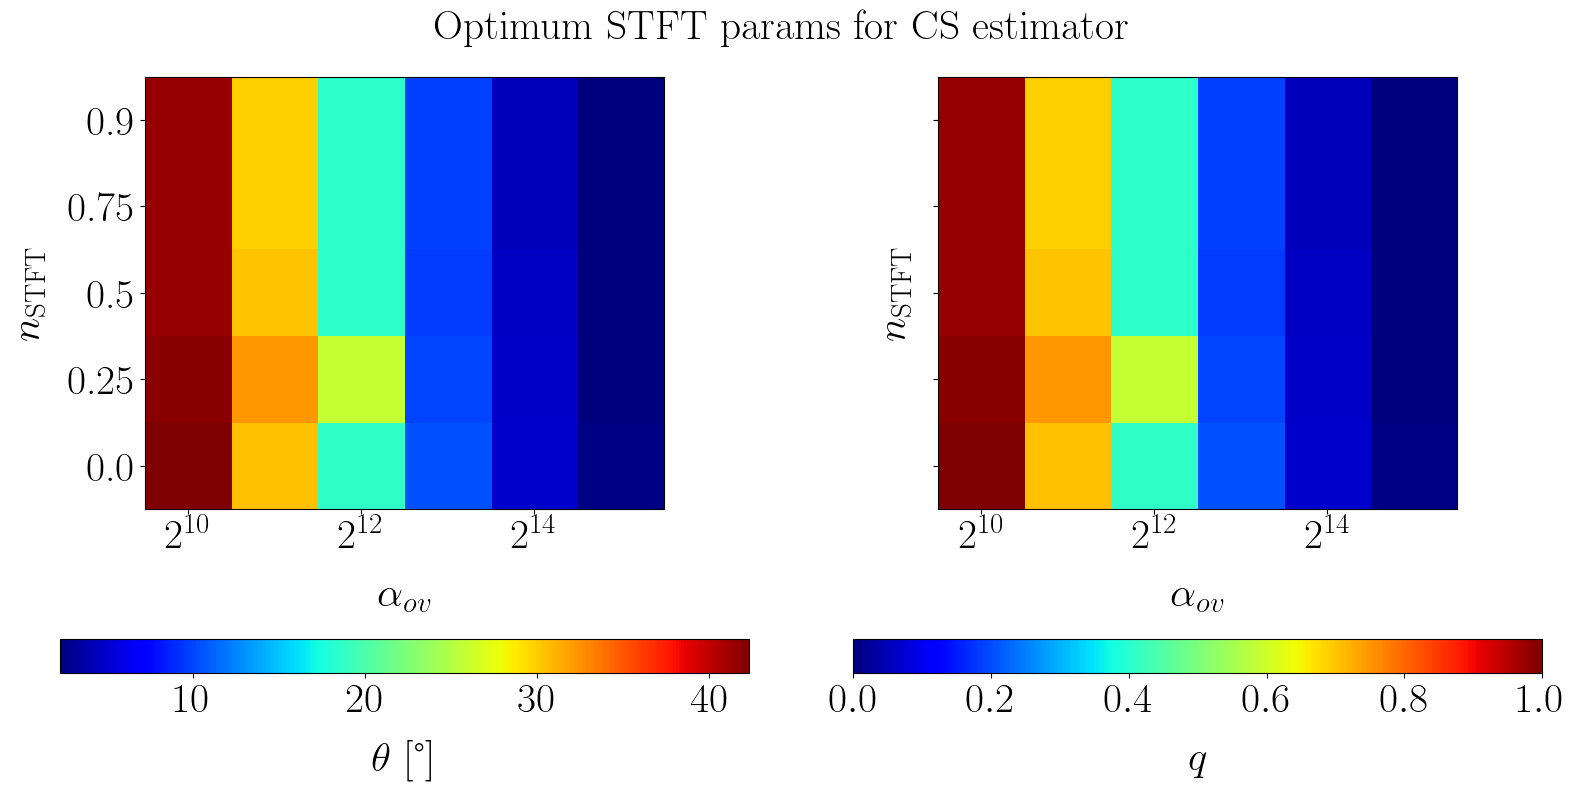

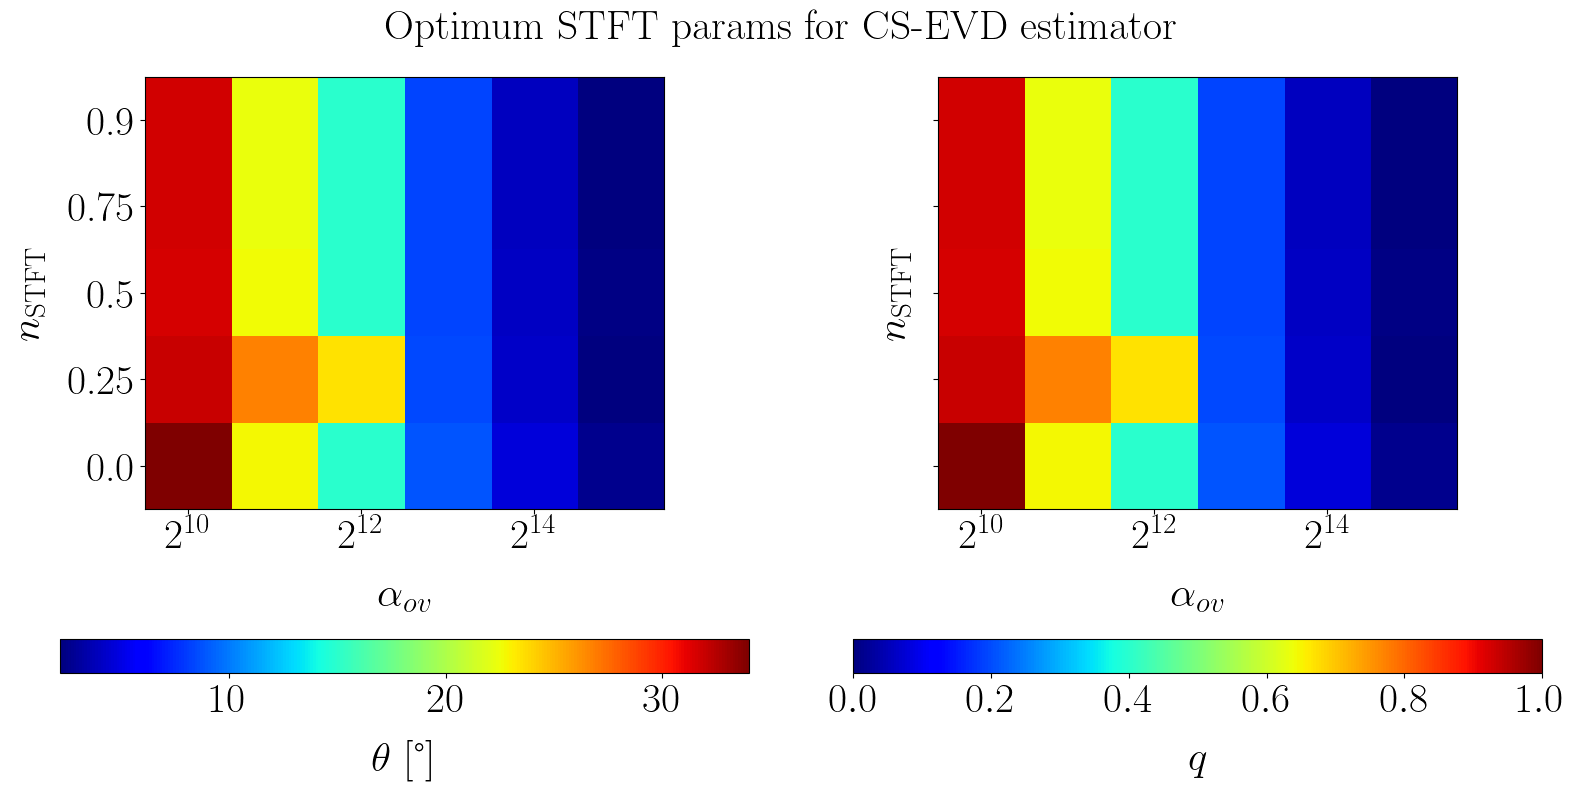

In [49]:
# Plot results
alpha_ovv, n_pow2_pp = np.meshgrid(ov_factors, n_stft_pow2)
if plot_minimisation_results:

    for rtf_e in rtf_estimators:
        theta_surf_mean = theta_mean_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_mean = normalize_metric_contrast(theta_surf_mean)
        q_mean_dB = 10 * np.log10(q_mean + 1e-1)

        theta_surf_med = theta_med_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_med = normalize_metric_contrast(theta_surf_med)

        theta_surf_sum = theta_sum_over_pos[rtf_e].reshape(n_pow2_pp.shape)
        q_sum = normalize_metric_contrast(theta_surf_sum)

        fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True)

        ax = axs[0]
        im = ax.imshow(theta_surf_med.T, cmap="jet", origin="lower")
        ax.set_yticks(np.arange(len(ov_factors)))
        ax.set_yticklabels(ov_factors)
        ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
        ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

        # ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
        ax.set_xlabel(r"$\alpha_{ov}$")
        ax.set_ylabel(r"$n_{\textrm{STFT}}$")
        plt.colorbar(ax=ax, mappable=im, label=r"$\theta$ [°]", orientation="horizontal")

        ax = axs[1]
        im = ax.imshow(q_med.T, cmap="jet", vmin=0, vmax=1, origin="lower")
        colorbarlabel = r"$q$"
        # im = ax.imshow(q_mean_dB.T, cmap="jet",  vmin=-10, vmax=0, origin="lower")
        # colorbarlabel = r"$q$ [dB]"

        ax.set_yticks(np.arange(len(ov_factors)))
        ax.set_yticklabels(ov_factors)
        ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
        ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])

        # ax.pcolormesh(alpha_ovv, n_pp, theta_pos, cmap="jet")
        ax.set_xlabel(r"$\alpha_{ov}$")
        ax.set_ylabel(r"$n_{\textrm{STFT}}$")
        plt.colorbar(ax=ax, mappable=im, label=colorbarlabel, orientation="horizontal")
        fig.suptitle(f"Optimum STFT params for {rtf_e.upper()} estimator")

        # Save

        # fpath = os.path.join(
        #     stft_twmin_params_folder, f"{rtf_e}_mean_theta_and_q_over_all_positions.png"
        # )
        # plt.savefig(fpath)

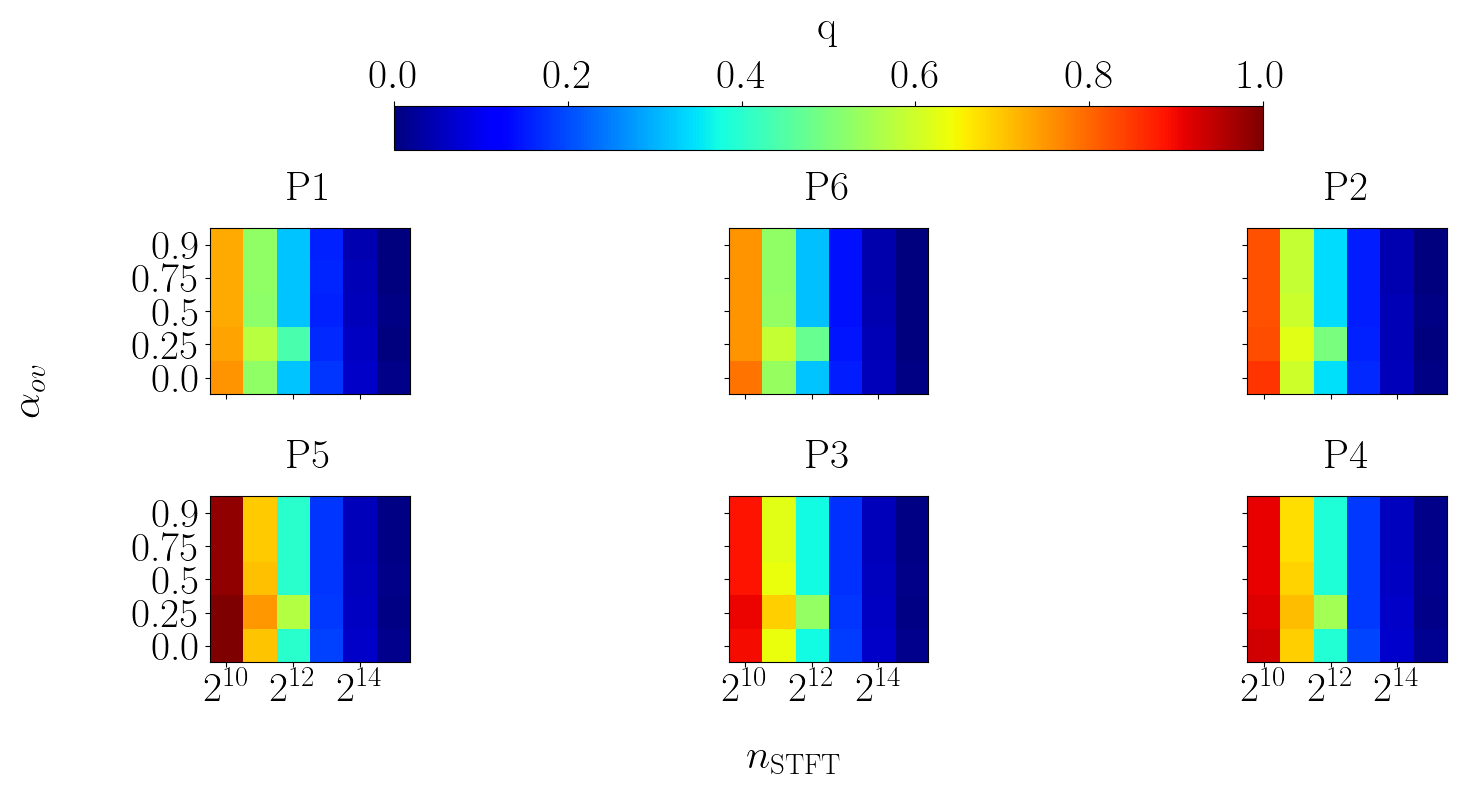

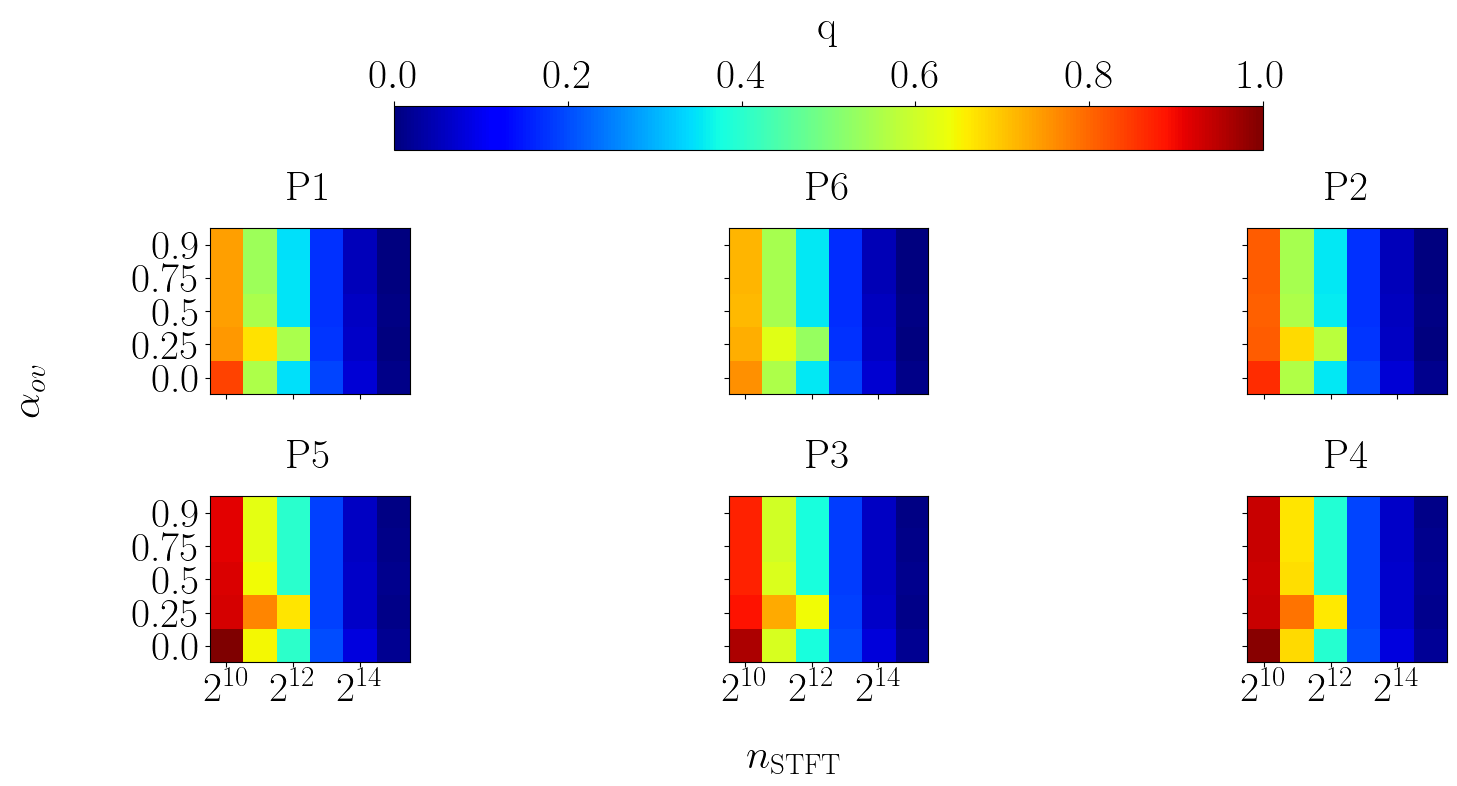

In [50]:
# Plot for each position
if plot_minimisation_results:
    for rtf_e in rtf_estimators:
        q_all_pos = normalize_metric_contrast(theta_all_pos[rtf_e])
        fig, axs = plt.subplots(nrows=2, ncols=3, sharex=True, sharey=True)

        for ipos, pos in enumerate(src_label_sorted):
            ax = axs[ipos // 3, ipos % 3]
            q_pos = q_all_pos[ipos, :].reshape(n_pow2_pp.shape)
            im = ax.imshow(q_pos.T, cmap="jet", vmin=0, vmax=1, origin="lower")
            ax.set_yticks(np.arange(len(ov_factors)))
            ax.set_yticklabels(ov_factors)
            ax.set_xticks(np.arange(len(n_stft_pow2))[::2])
            ax.set_xticklabels([r"$2^{" + str(n) + "}$" for n in n_stft_pow2][::2])
            ax.set_title(pos)

        fig.colorbar(
            im, ax=axs, orientation="horizontal", fraction=0.1, location="top", label="q"
        )
        fig.supylabel(r"$\alpha_{ov}$")
        fig.supxlabel(r"$n_{\textrm{STFT}}$")

        # # Save
        # fpath = os.path.join(stft_twmin_params_folder, f"{rtf_e}_q_each_position.png")
        # plt.savefig(fpath)

## Impact sur la segmentation signal / bruit 

La taille des fenêtres STFTs joue également sur la capacité à segmenter correctement le signal reçu en période signal + bruit et bruit. 

Il faut donc s'assurer que le choix de paramètres permet effectivement une segmentation efficace. 

In [51]:
data_dynamic = xr.open_dataset(
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic\10-10-2024T16-53-43-200271_PR_N1_346.nc"
)

Text(0.5, 1.0, 'Rcv 0 - (n_stft = 16384, alpha = 0.5)')

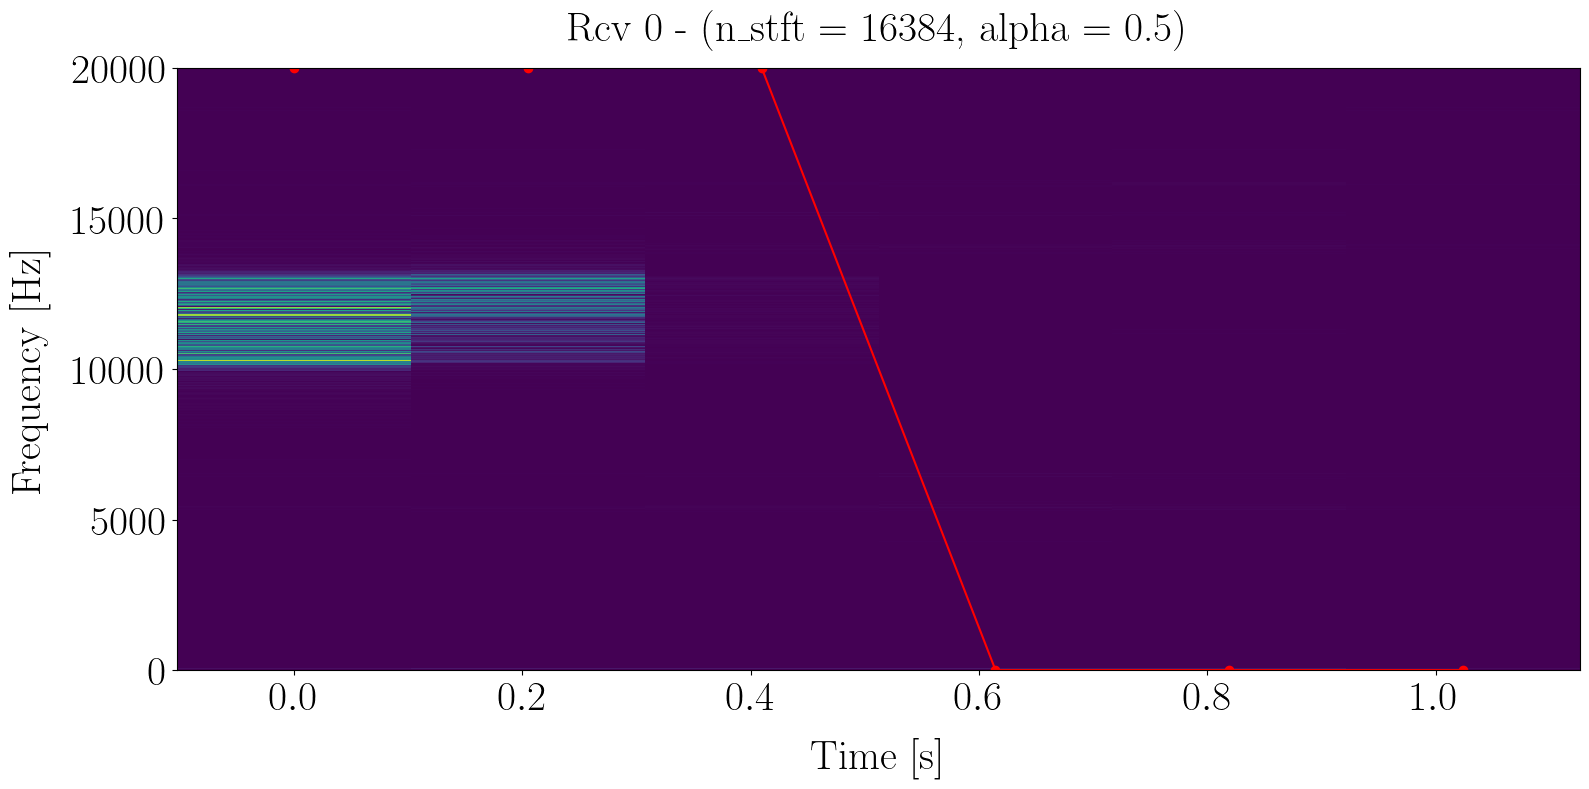

In [52]:
# Show segmentation results
fsm_split = FiberscopeManager(root_processed_data=root_data)

# Set stft params
alpha = 0.5
fsm_split.nperseg = 2**14
fsm_split.noverlap = int(fsm_split.nperseg * alpha)

# data_ = data_dynamic.sel(time=slice(0, 200))
data_ = data_dynamic.sel(time=slice(10, 11))
x = data_.signal.T
fs = data_.fs

ff, tt, stft_x = fsm_split.cm.get_stft_array(
    x, fs=fs, nperseg=fsm_split.nperseg, noverlap=fsm_split.noverlap
)

# Get mask defining signal+noise period
tt, mask_tt_x = fsm_split.get_signal_presence_mask(
    x, fs=fs, nperseg=fsm_split.nperseg, noverlap=fsm_split.noverlap
)
mask_tt_v = ~mask_tt_x

# Plot stft
idx_rcv = 0
plt.figure()
plt.pcolormesh(tt, ff, np.abs(stft_x[idx_rcv, ...]))

mask_tt_x_norm = mask_tt_x.astype(int) * np.max(ff)
plt.plot(tt, mask_tt_x_norm, color="r", marker="o")

# plt.xlim([0, 20])
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"Rcv {idx_rcv} - (n_stft = {fsm_split.nperseg}, alpha = {alpha})")

Text(0.5, 1.0, 'Rcv 0 - (n_stft = 32768, alpha = 0.5)')

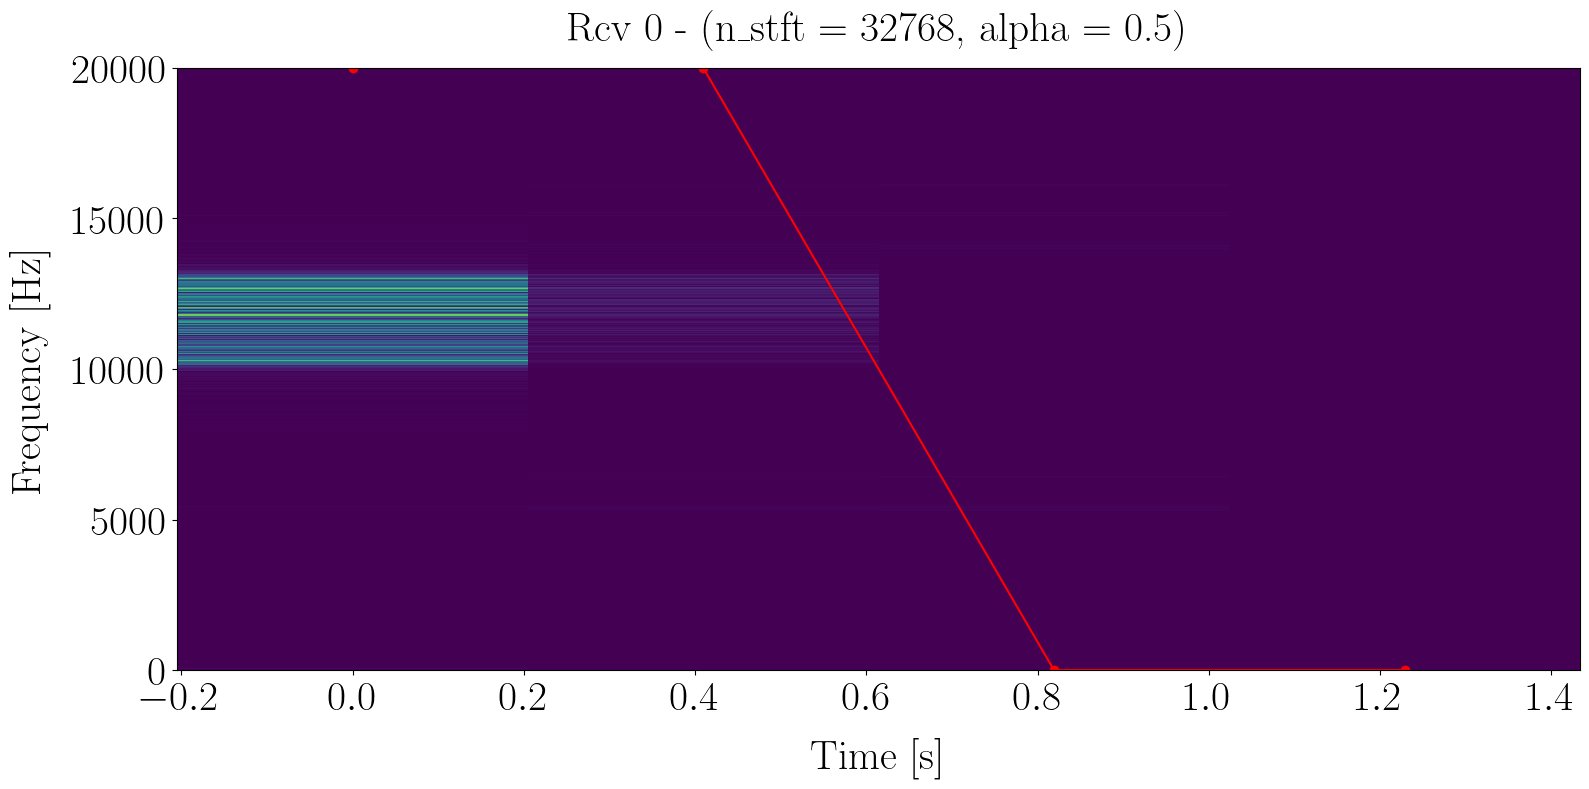

In [53]:
# Set stft params
alpha = 0.5
fsm_split.nperseg = 2**15
fsm_split.noverlap = int(fsm_split.nperseg * alpha)

ff, tt, stft_x = fsm_split.cm.get_stft_array(
    x, fs=fs, nperseg=fsm_split.nperseg, noverlap=fsm_split.noverlap
)

# Get mask defining signal+noise period
tt, mask_tt_x = fsm_split.get_signal_presence_mask(
    x, fs=fs, nperseg=fsm_split.nperseg, noverlap=fsm_split.noverlap
)
mask_tt_v = ~mask_tt_x

# Plot stft
idx_rcv = 0
plt.figure()
plt.pcolormesh(tt, ff, np.abs(stft_x[idx_rcv, ...]))

mask_tt_x_norm = mask_tt_x.astype(int) * np.max(ff)
plt.plot(tt, mask_tt_x_norm, color="r", marker="o")

# plt.xlim([0, 20])
plt.xlabel("Time [s]")
plt.ylabel("Frequency [Hz]")
plt.title(f"Rcv {idx_rcv} - (n_stft = {fsm_split.nperseg}, alpha = {alpha})")

### Commentaires

Ces deux figures permettent de vérifier que la procédure de segmentation fonctionne correctement pour les paramètres retenus. 

Cette étape à permis d'adapter la fonction de segmentation afin d'améliorer la procédure. 

Une fois les corrections apportées, il semble que le choix $n_{stft} = 2^{15}$ puisse être appliqué. 

## Calcul du SNR de l'enregistrement dynamique 

Il peut être utile de donner le SNR afin de souligner que l'on est ici dans un cas très favorable. 

Pour ce faire, on calcule le SNR moyen sur tout l'enregistrement dans la bande du signal (10-13 kHz). 


In [54]:
# rcv = 0
# # x_rcv = data_.sel(h_index=data.h_index.values[rcv]).sel(time=slice(250, 255)).signal
# x_rcv = data_.sel(h_index=data.h_index.values[rcv]).sel(time=slice(0, 255)).signal


# # Compute rolling variance (=power)
# window_length = 2**16
# power_rcv = x_rcv.rolling(time=window_length, center=True).var()
# plt.figure()
# plt.plot(data_.time, power_rcv)
# x_rcv.plot()
# plt.xlabel("Time [s]")
# plt.ylabel("Rolling variance (power)")
# plt.title(f"Rcv {rcv} - Rolling variance over {window_length/fs:.2f} s window")

## Définition des paramètres optimaux à utiliser pour la suite 

In [55]:
# Save optimum properties
opti_stft_props = {
    "n_stft": {
        "cs": 2**15,
        "cs-evd": 2**15,
    },
    "alpha_ov": {
        # # Indépendance statistique 
        # "cs": 0,
        # "cs-evd": 0,
        # Cohérence avec le cas test Zhang et al 2023
        "cs": 0.5,
        "cs-evd": 0.5,
    },
}

## Bilan étape 2

Les performances estimateurs dépendent principalement de la taille des fenêtres STFT considérées.

Les variations en fonctions du paramètre de recouvrement sont faibles et  deux choix sont possibles : 

* Choisir $\alpha_{ov} = 0$ pour respecter l'hypothèse d'indépendance statistique des segments. 
* Choisir $\alpha_{ov} = 0.5$, qui est un paramètre couramment utilisé et qui est cohérent avec le paramètre utilisé dans le cas test Zhang et al. 2023 utilisé pour la partie simulation du papier JASA EL. 



# Etape 3 : mise en oeuvre de la localisation RTF-MFP

In [56]:
n_lfm=1
theta_statistics = ["mean", "expectation"]
# theta_statistics = ["mean"]

rtf_estimators = ["cs", "cs-evd"]

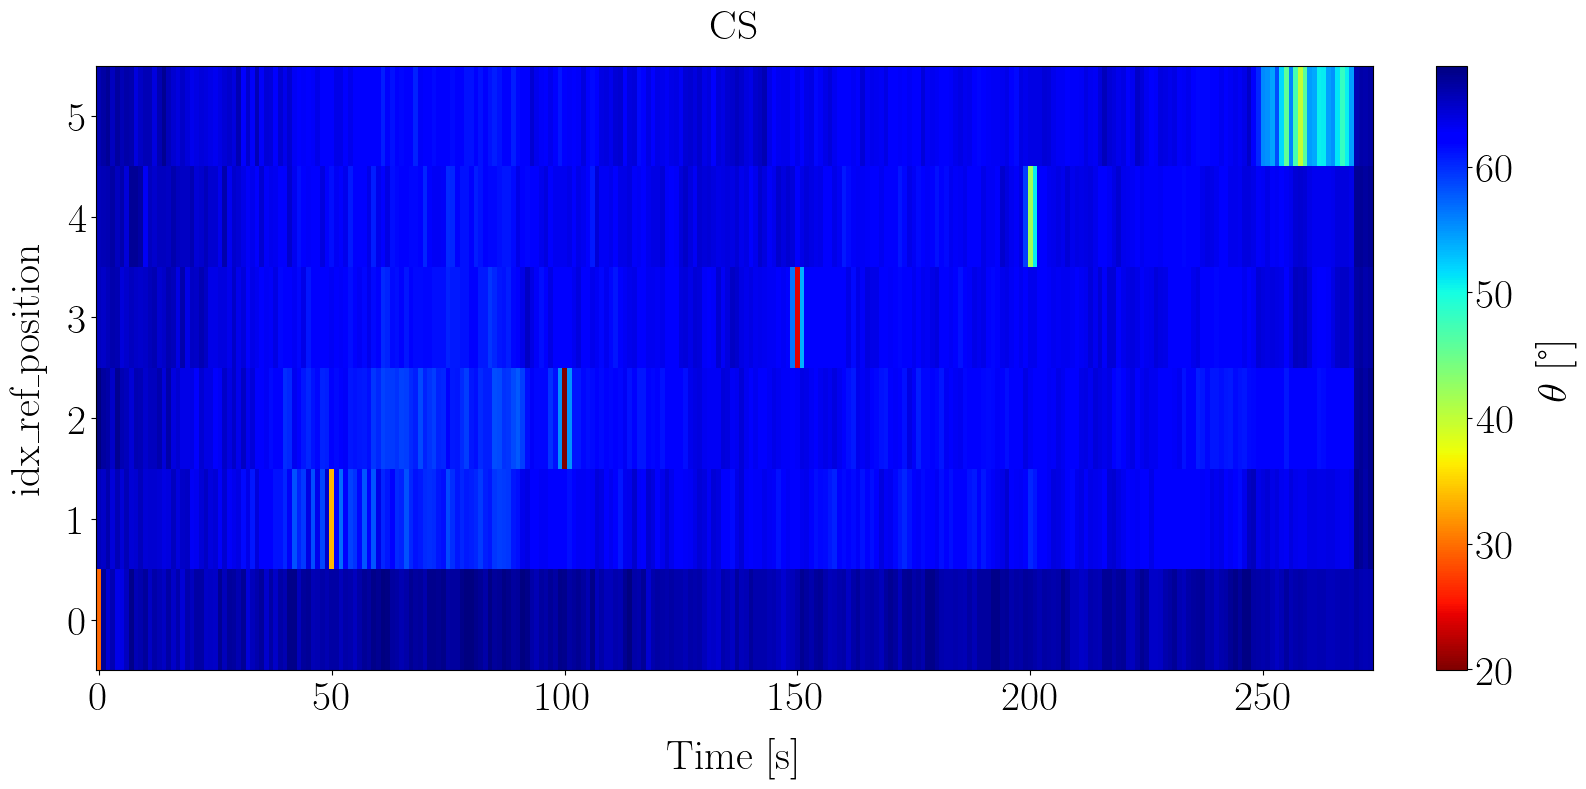

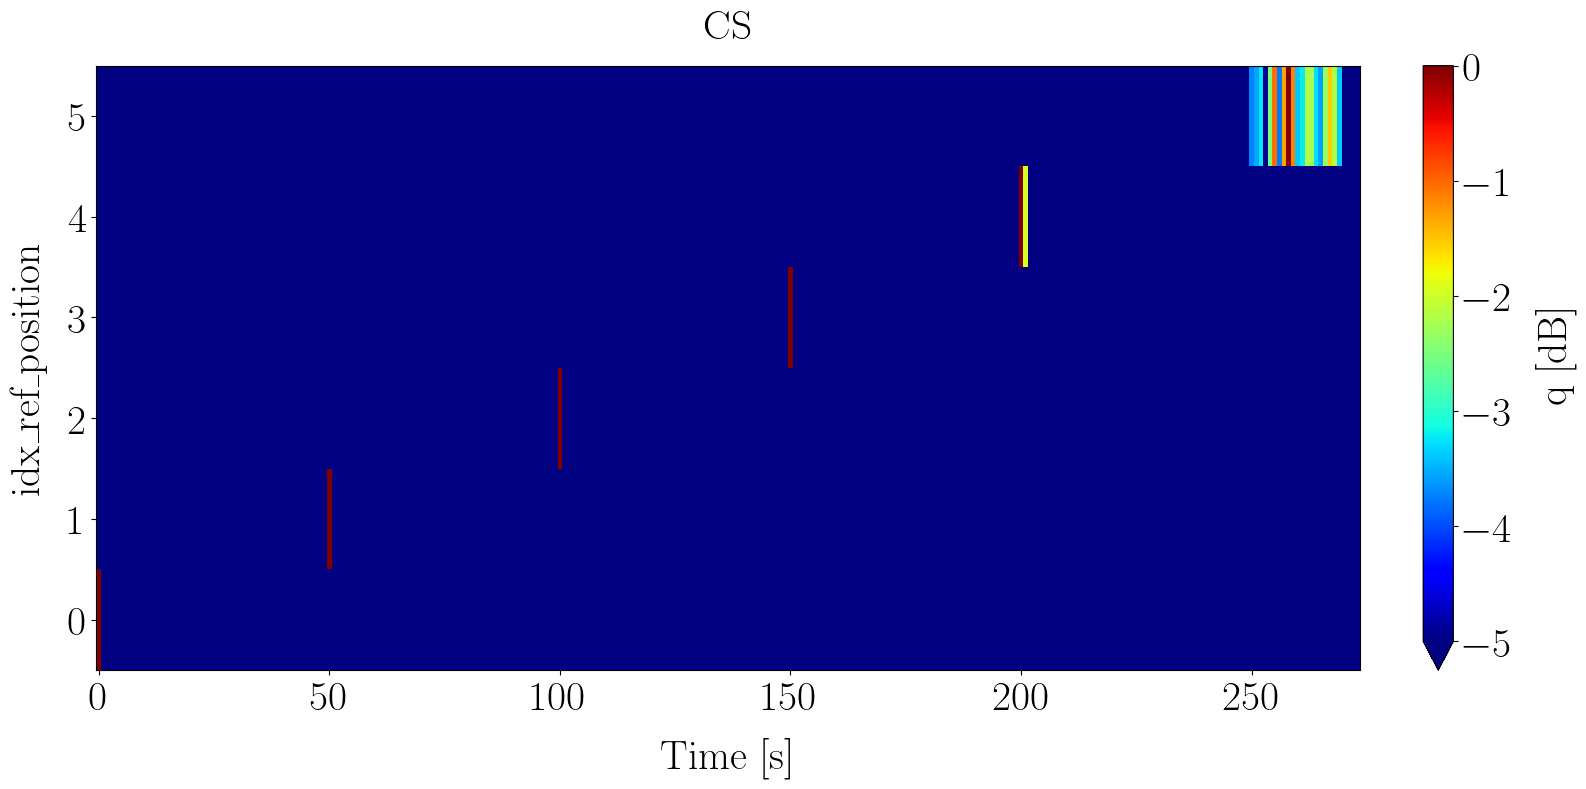

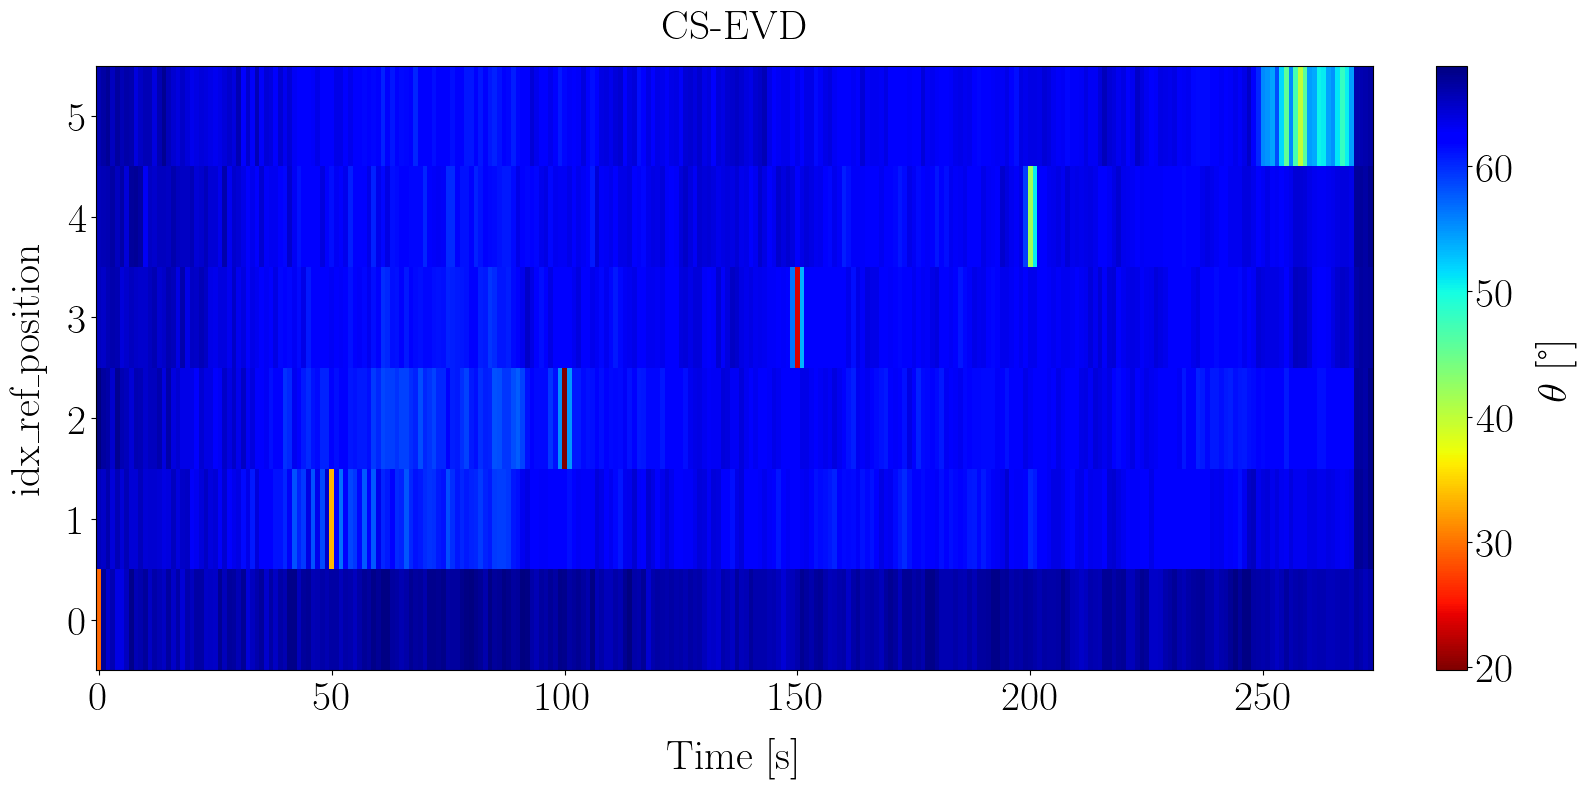

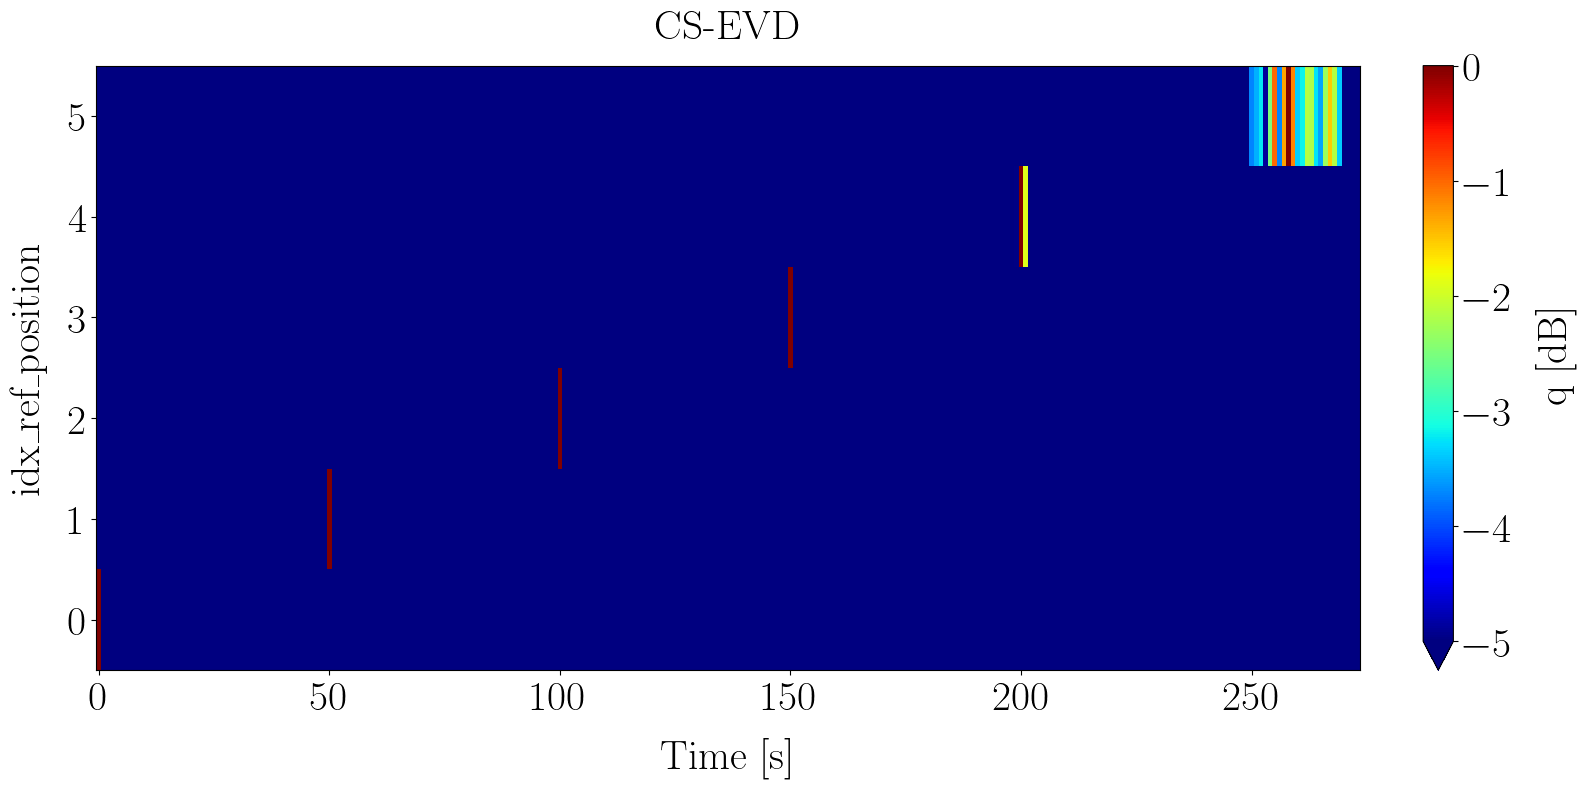

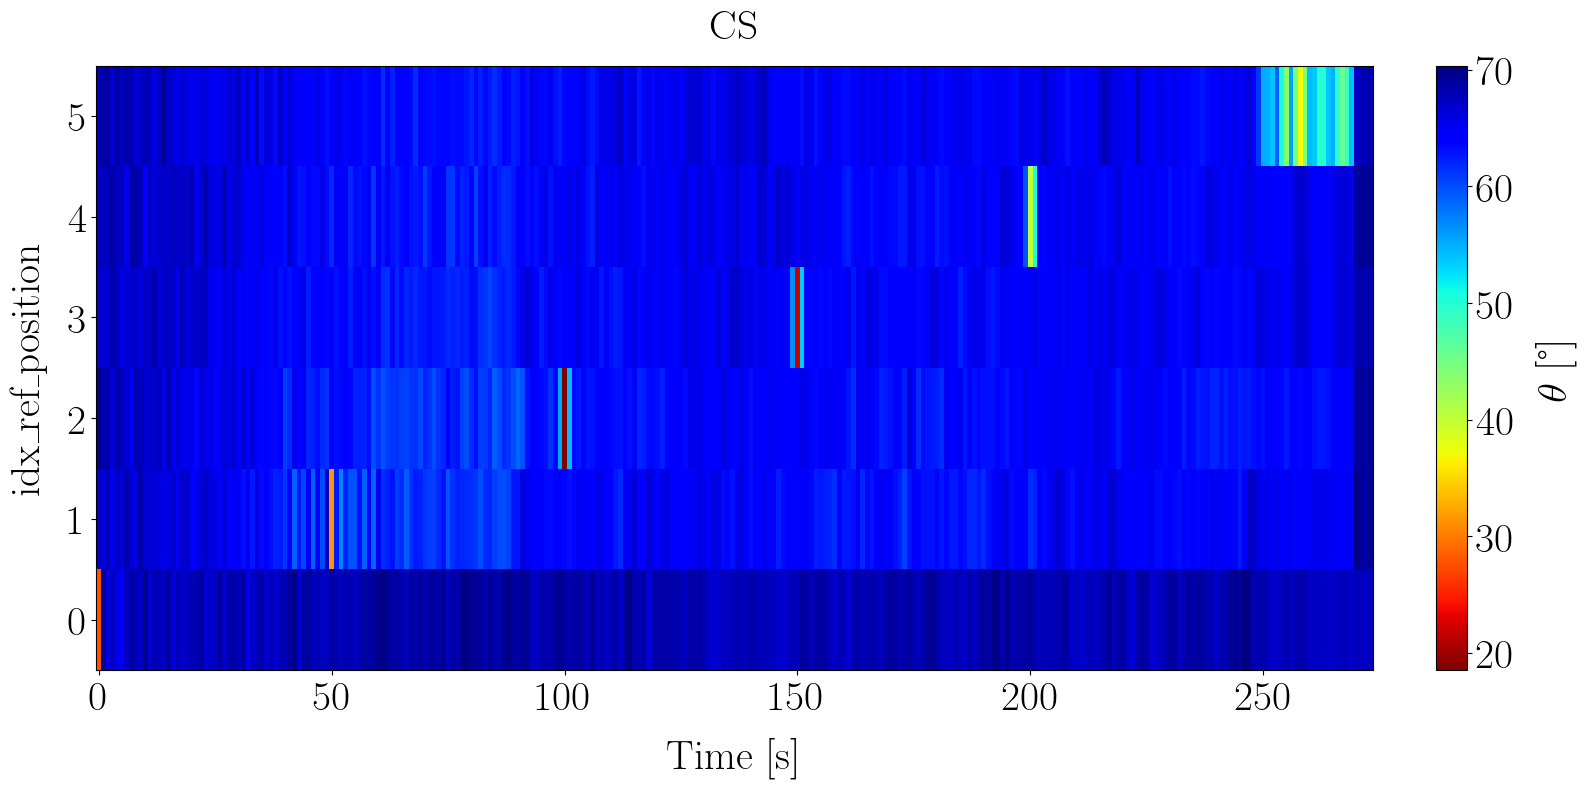

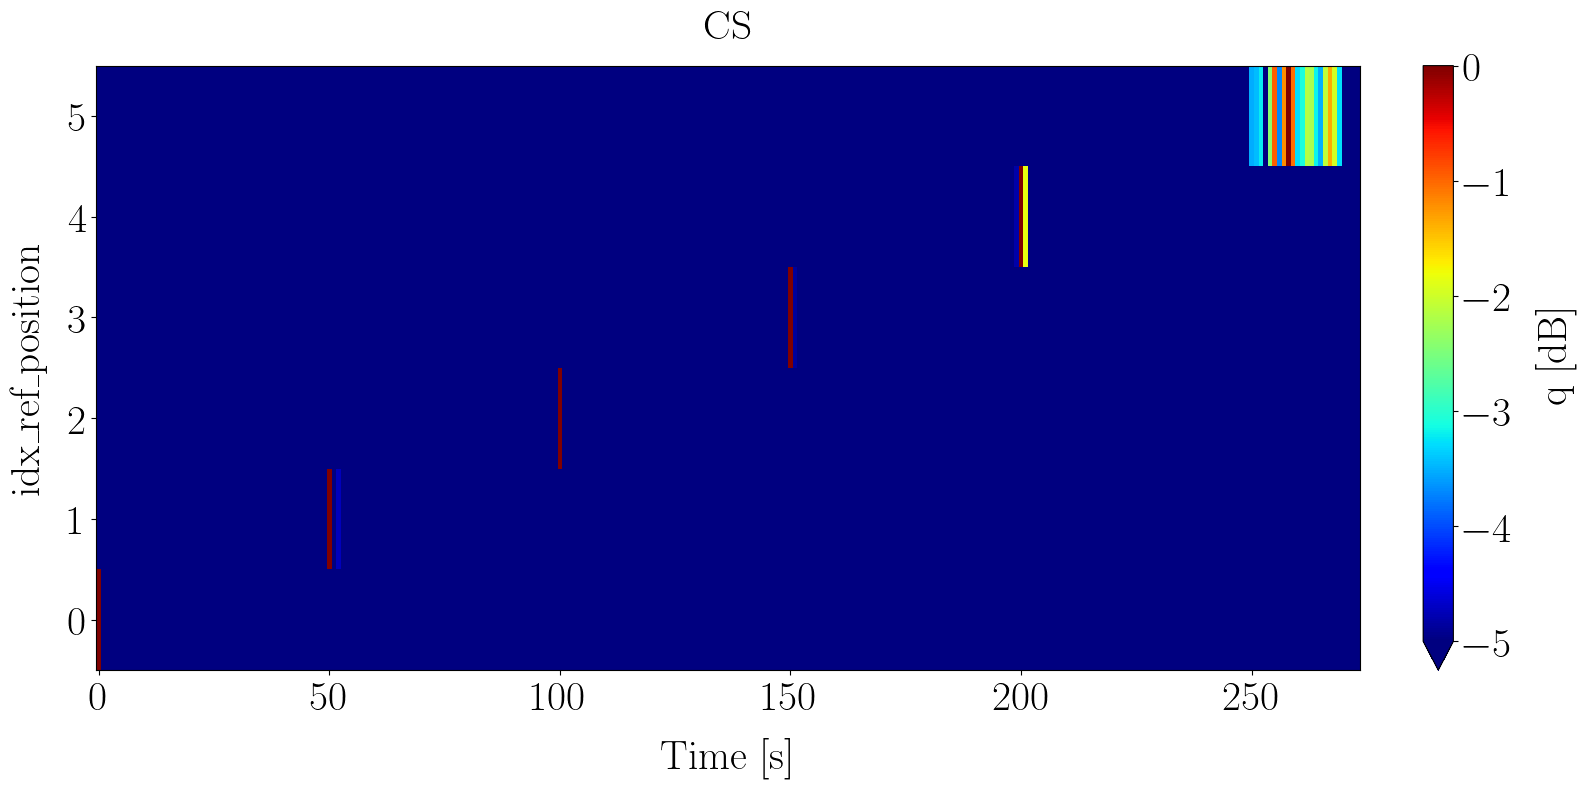

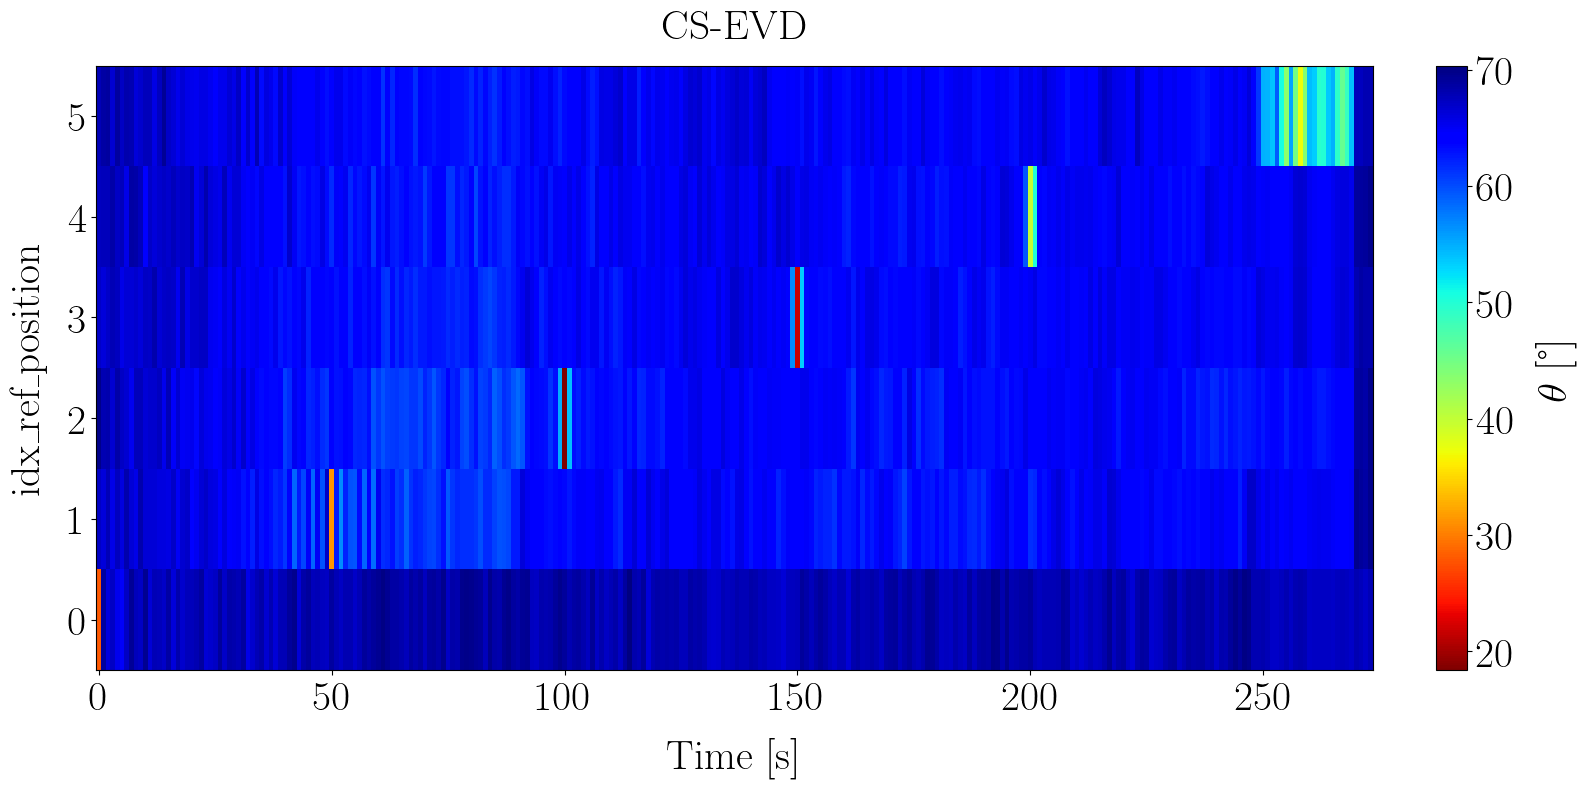

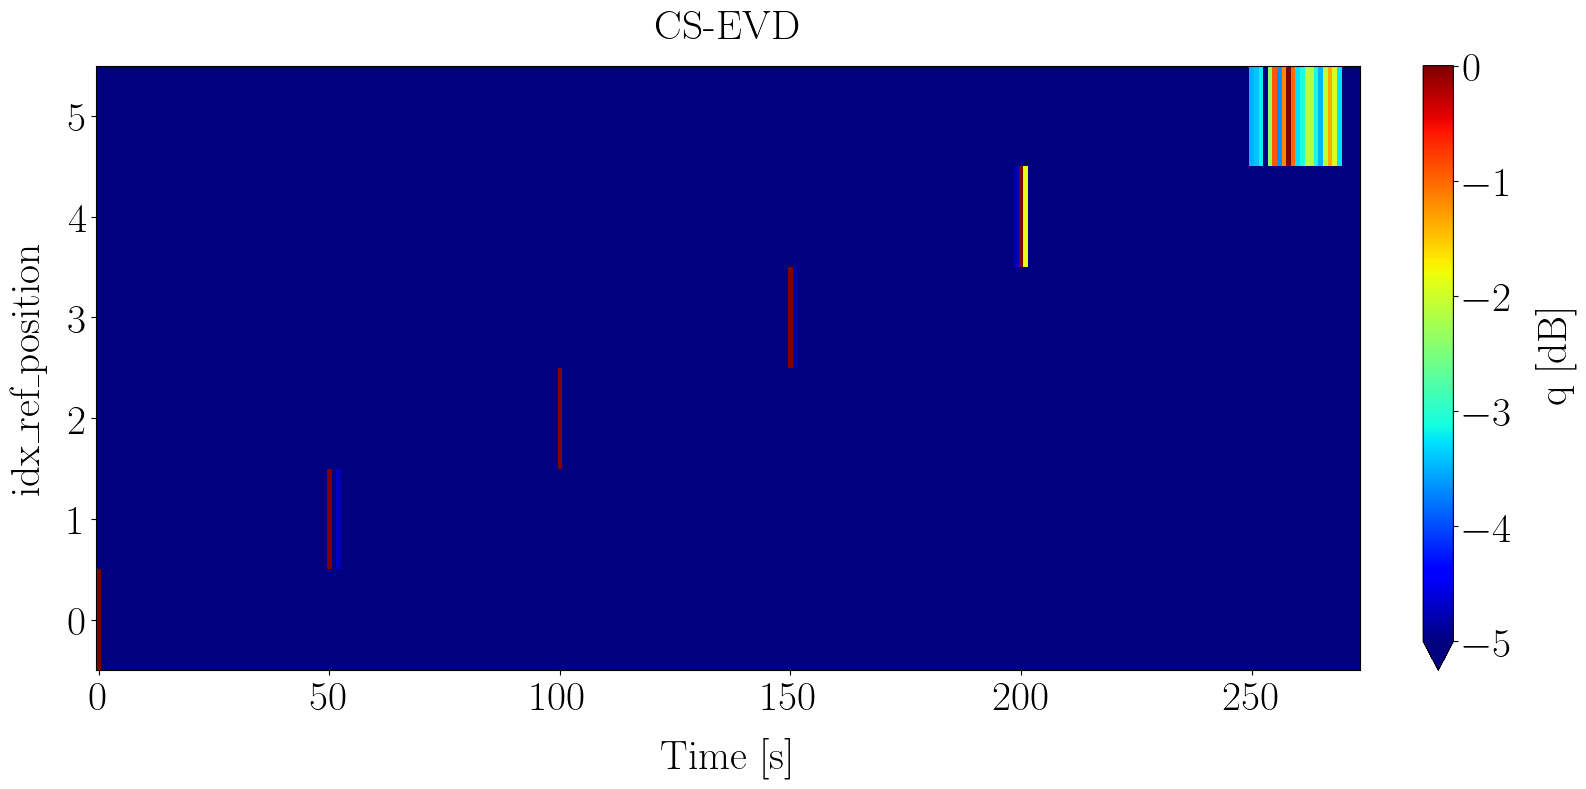

In [57]:
rtf_mfp_results = {rtf_e: {theta_stat: None for theta_stat in theta_statistics} for rtf_e in rtf_estimators}
if run_rtf_mfp:
    for theta_stat in theta_statistics:
        for rtf_e in rtf_estimators:
            nperseg = opti_stft_props["n_stft"][rtf_e]
            noverlap = int(nperseg * opti_stft_props["alpha_ov"][rtf_e])
            rtf_mfp_distance_map = apply_rtf_mfp(
                n_lfm=n_lfm,
                nperseg=nperseg,
                noverlap=noverlap,
                root_data=root_data,
                root_results=root_results,
                rtf_estimator=rtf_e,
                theta_statistics=theta_stat,
                h_index_ref=h_index_ref,
                verbose=False,
            )

            # Plot theta
            plt.figure()
            rtf_mfp_distance_map.theta.plot(x="time", cmap="jet_r")
            plt.title(rtf_e.upper())

            # Plot q_dB
            plt.figure()
            rtf_mfp_distance_map.q_dB.plot(x="time", cmap="jet", vmin=-5)
            plt.title(rtf_e.upper())

            plt.show()
            plt.close("all")
            # Store for comparison
            rtf_mfp_results[rtf_e][theta_stat] = rtf_mfp_distance_map

else:
    for theta_stat in theta_statistics:
        for rtf_e in rtf_estimators:
            # Load pre-computee datasets
            signal_duration = n_lfm * fs_sweep.interp_pulse_period
            fpath = os.path.join(
                root_results,
                f"rtf_mfp_distance_map_Tw{signal_duration}_{theta_stat}_{rtf_e}.nc",
            )
            rtf_mfp_distance_map = xr.open_dataset(fpath)

            # Plot theta
            plt.figure()
            rtf_mfp_distance_map.theta.plot(x="time", cmap="jet_r")
            plt.title(rtf_e.upper())

            # Plot q_dB
            plt.figure()
            rtf_mfp_distance_map.q_dB.plot(x="time", cmap="jet", vmin=-5)
            plt.title(rtf_e.upper())

            plt.show()
            plt.close("all")

            # Store for comparison
            rtf_mfp_results[rtf_e][theta_stat] = rtf_mfp_distance_map

            # Store for comparison
            rtf_mfp_results[rtf_e][theta_stat] = rtf_mfp_distance_map

## Comparaison CS vs CS-EVD (mean vs expectation)

### Angle hermitien $\theta$

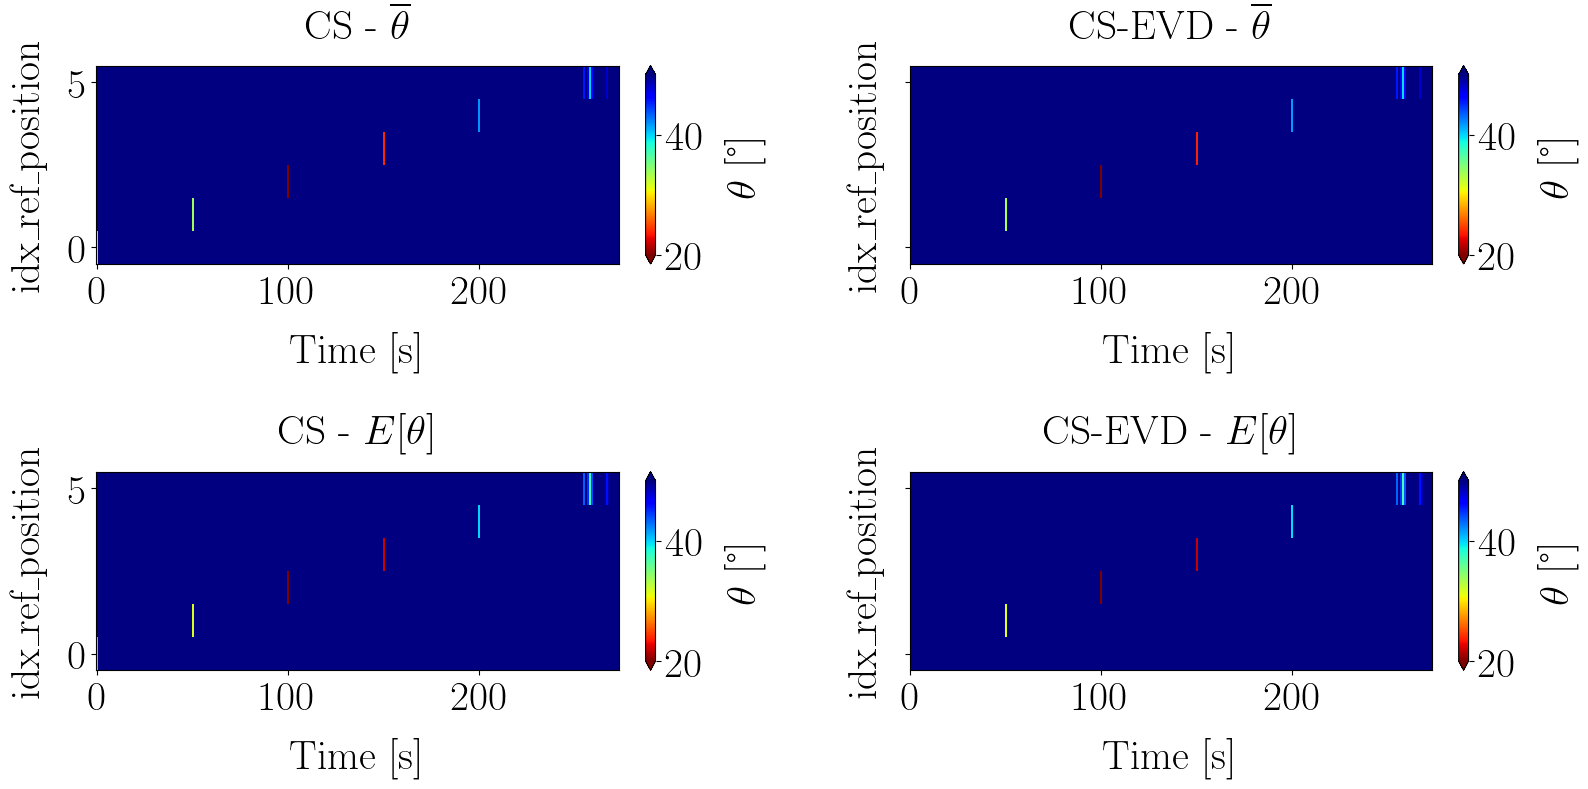

In [58]:
theta_stat_label = {
    "mean": r"$\overline{\theta}$",
    "expectation": r"$E[\theta]$",
}
fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True)
for i, theta_stat in enumerate(theta_statistics):
    for j, rtf_e in enumerate(rtf_estimators):
        ax = axs[i, j]
        distmap = rtf_mfp_results[rtf_e][theta_stat]
        distmap.theta.plot(x="time", cmap="jet_r", vmin=20, vmax=50, ax=ax)
        ax.set_title(f"{rtf_e.upper()} - {theta_stat_label[theta_stat]}")

### Constraste q

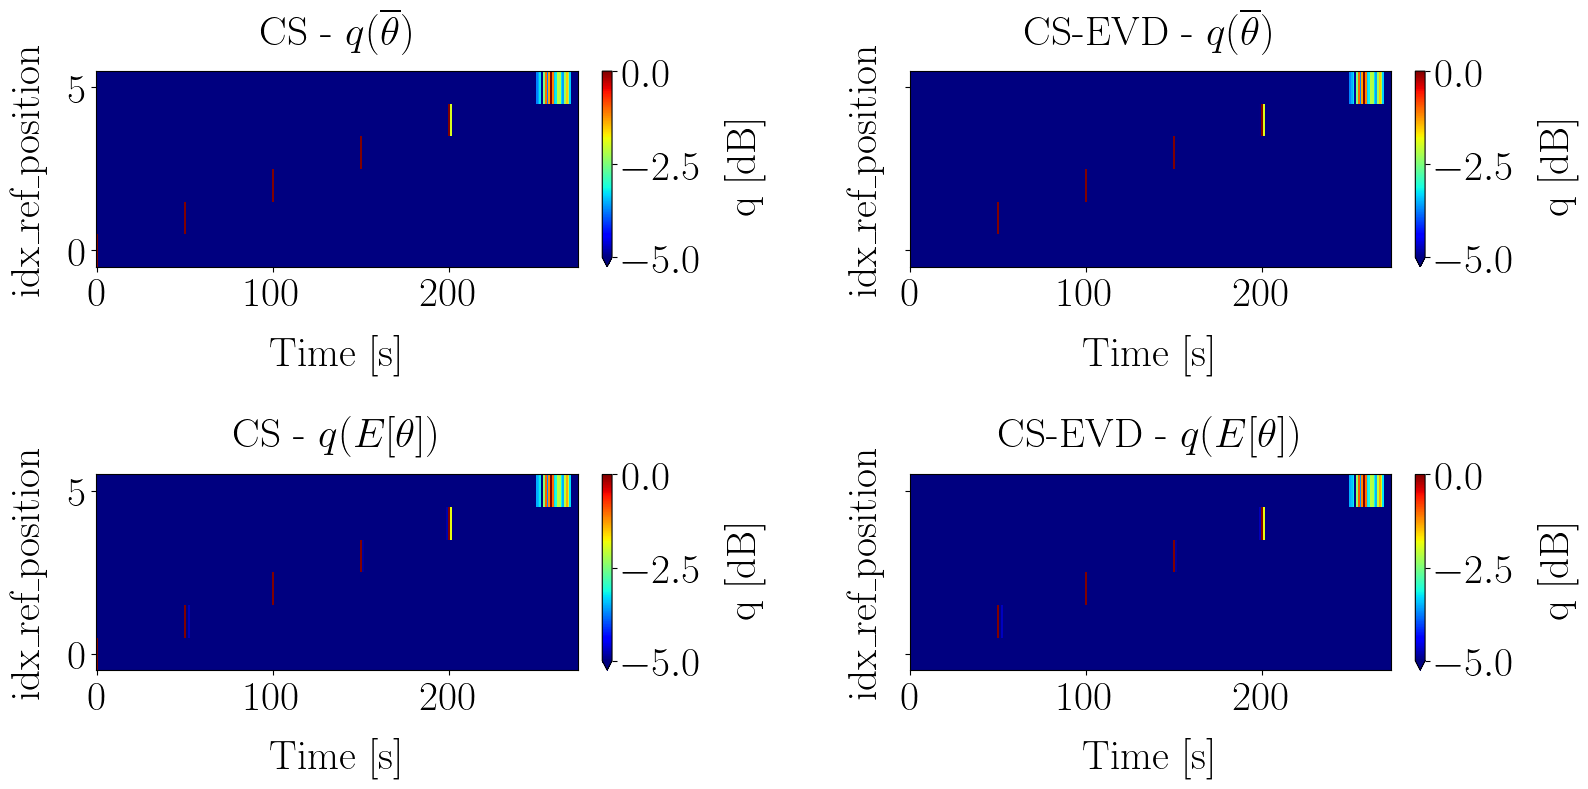

In [59]:
q_theta_stat_label = {
    "mean": r"$q(\overline{\theta})$",
    "expectation": r"$q(E[\theta])$",
}
fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True)
for i, theta_stat in enumerate(theta_statistics):
    for j, rtf_e in enumerate(rtf_estimators):
        ax = axs[i, j]
        distmap = rtf_mfp_results[rtf_e][theta_stat]
        distmap.q_dB.plot(x="time", cmap="jet", vmin=-5, vmax=0, ax=ax)
        ax.set_title(f"{rtf_e.upper()} - {q_theta_stat_label[theta_stat]}")

### Commentaires 

Il est difficile de voir une quelconque différence entre les deux méthodes et les deux modes de calcul de la distance caractéristique à partir de ces 4 figures. 

Les 4 configurations permettent de localiser la source en mouvement de manière satisfaisante avec un très bon contraste (et donc une faible ambiguïté). 

## Comparaison des 4 configurations 

Text(0.5, 1.0, '$\\overline{\\theta}^{(CS-EVD)} - E[\\theta]^{(CS-EVD)}$')

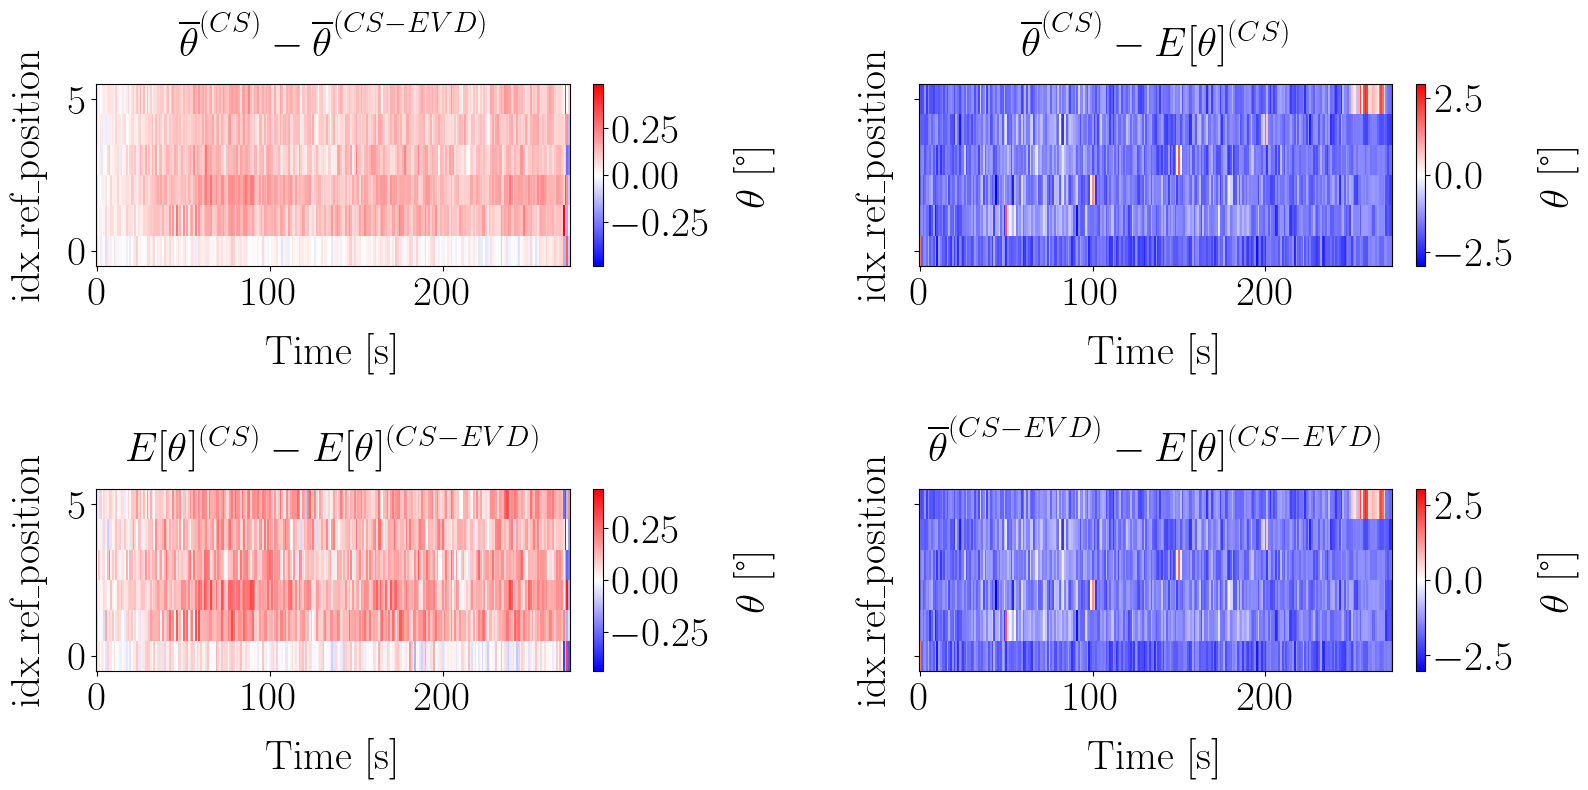

In [60]:
fig, axs = plt.subplots(nrows=2, ncols=2, sharey=True)

delta_csbar_cs_evdbar = rtf_mfp_results["cs"]["mean"] - rtf_mfp_results["cs-evd"]["mean"]
delta_csbar_cs_evdbar.theta.plot(x="time", cmap="bwr", ax=axs[0, 0])
axs[0, 0].set_title(r"$\overline{\theta}^{(CS)} - \overline{\theta}^{(CS-EVD)}$")

delta_csbar_csexp = (
    rtf_mfp_results["cs"]["mean"] - rtf_mfp_results["cs"]["expectation"]
)
delta_csbar_csexp.theta.plot(x="time", cmap="bwr", ax=axs[0, 1])
axs[0, 1].set_title(r"$\overline{\theta}^{(CS)} - E[\theta]^{(CS)}$")

delta_csexp_cs_evdexp = (
    rtf_mfp_results["cs"]["expectation"] - rtf_mfp_results["cs-evd"]["expectation"]
)
delta_csexp_cs_evdexp.theta.plot(x="time", cmap="bwr", ax=axs[1, 0])
axs[1, 0].set_title(r"$E[\theta]^{(CS)} - E[\theta]^{(CS-EVD)}$")

delta_cs_evdbar_cs_evdexp = rtf_mfp_results["cs-evd"]["mean"] - rtf_mfp_results["cs-evd"]["expectation"]
delta_cs_evdbar_cs_evdexp.theta.plot(x="time", cmap="bwr", ax=axs[1, 1])
axs[1, 1].set_title(r"$\overline{\theta}^{(CS-EVD)} - E[\theta]^{(CS-EVD)}$")


### Commentaires 

On ne peut a priori pas dire grand-chose des différences entre les deux méthodes CS et CS-EVD (colonne de gauche), ce qui compte, c'est le contraste de la surface d'ambiguïté. 

En revanche, les deux figures de la colonne de gauche permettent de voir que l'utilisation de l'espérance de la distribution des $\theta$ permet d'obtenir un meilleur contraste, i.e de meilleures performances de localisation. 

En effet : 

* Au niveau des positions de référence P1 à P6 les deux méthodes CS et CS-EVD exhibent une différence $\overline{\theta}^{(CS-EVD)} - E[\theta]^{(CS-EVD)} > 0$. Ceci signifie que l'espérance permet d'obtenir un angle plus faible caractéristique de la position recherchée. 

* Au contraire, pour le reste des segments la différence est négative $\overline{\theta}^{(CS-EVD)} - E[\theta]^{(CS-EVD)} < 0$ ce qui signifie que l'angle donné par l'espérance de la distribution est plus élevé caractéristique d'une position qui ne correspond pas. 

Globalement, le contraste est donc plus important dans le cas où l'on utilise l'espérance comme on peut l'illustrer ci-dessous. 

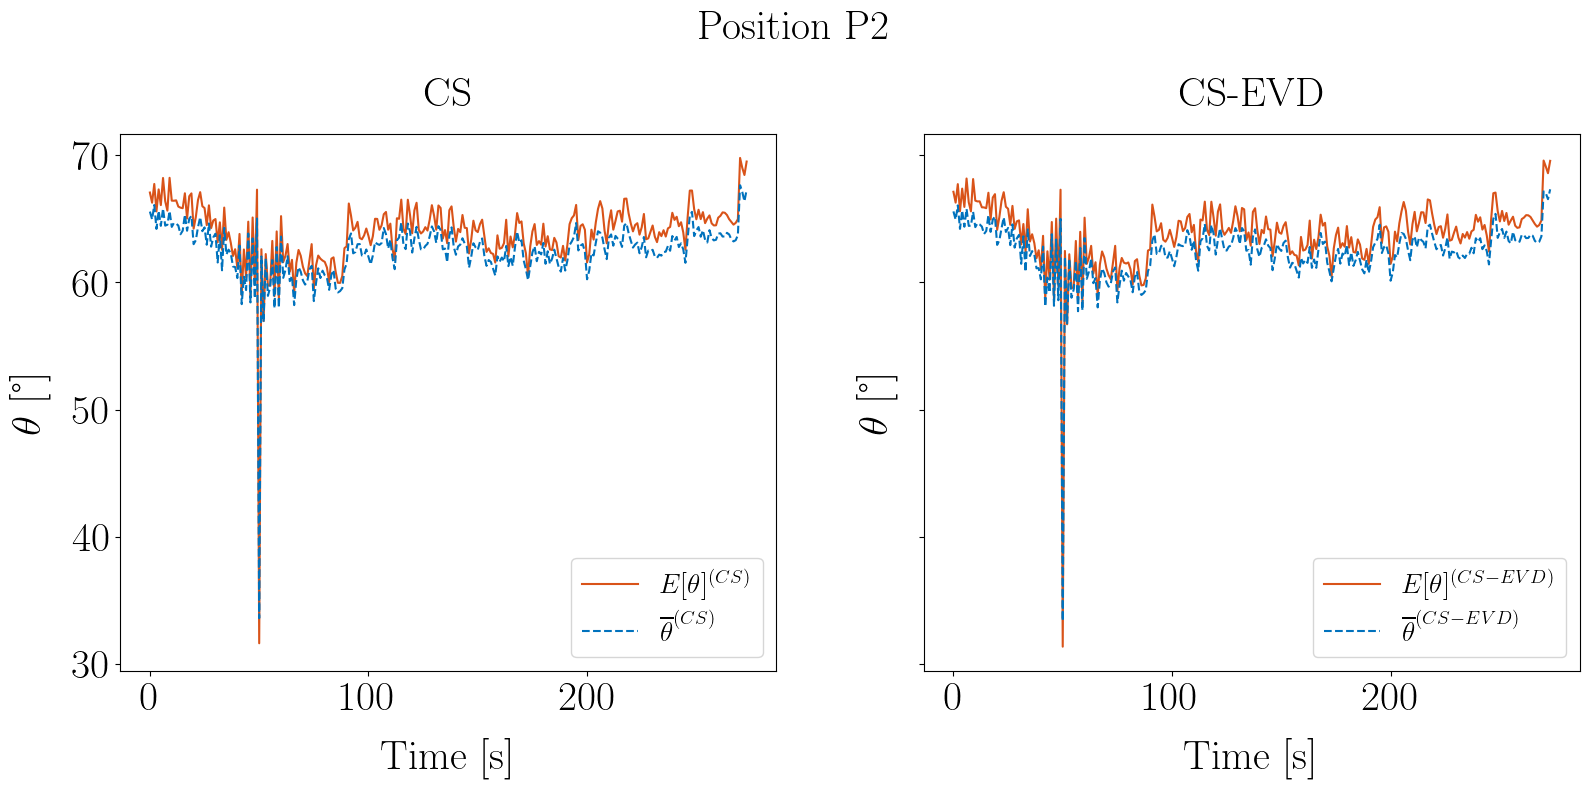

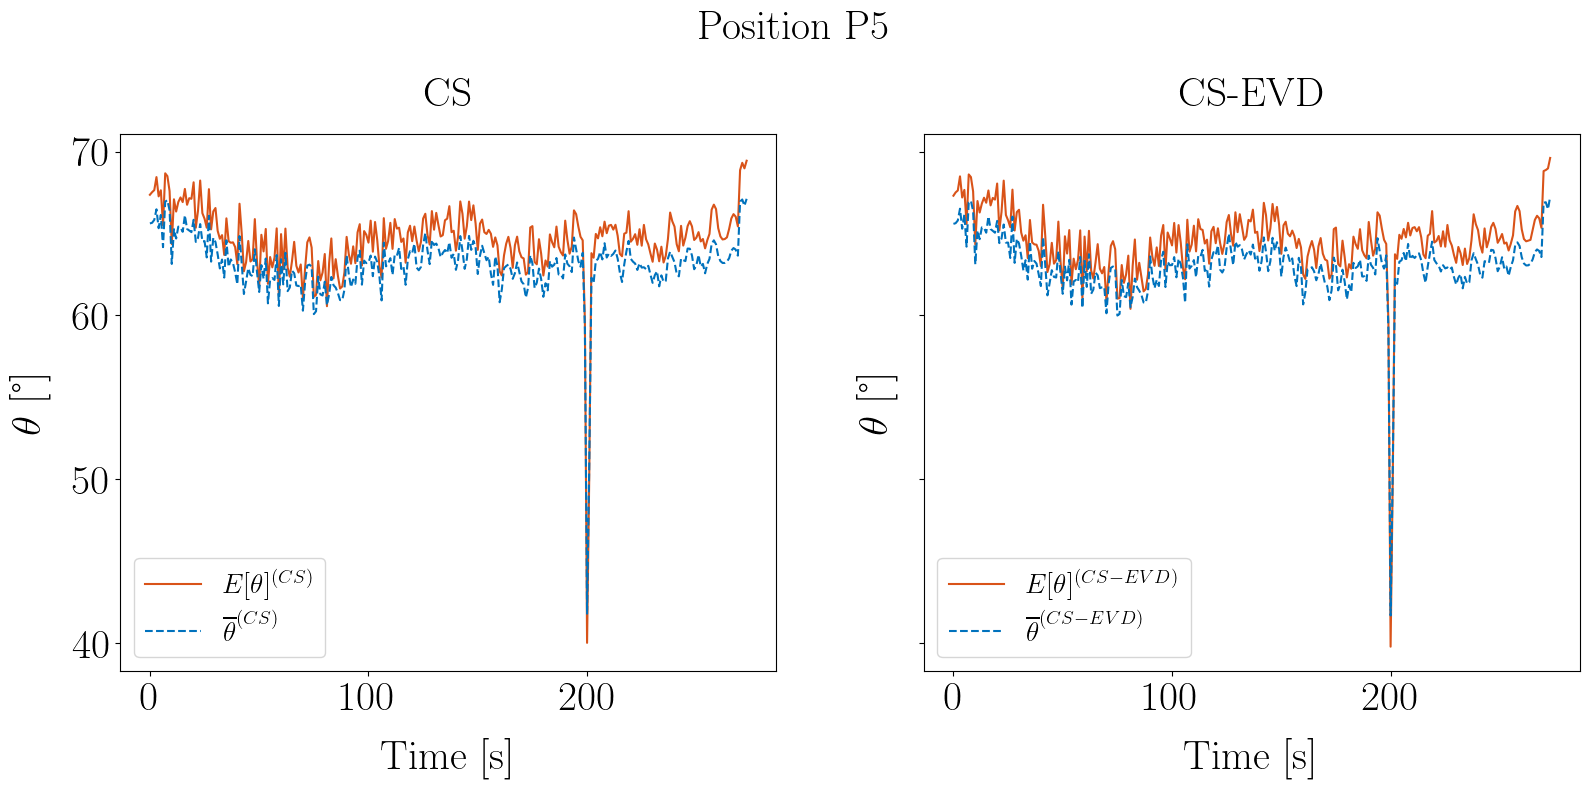

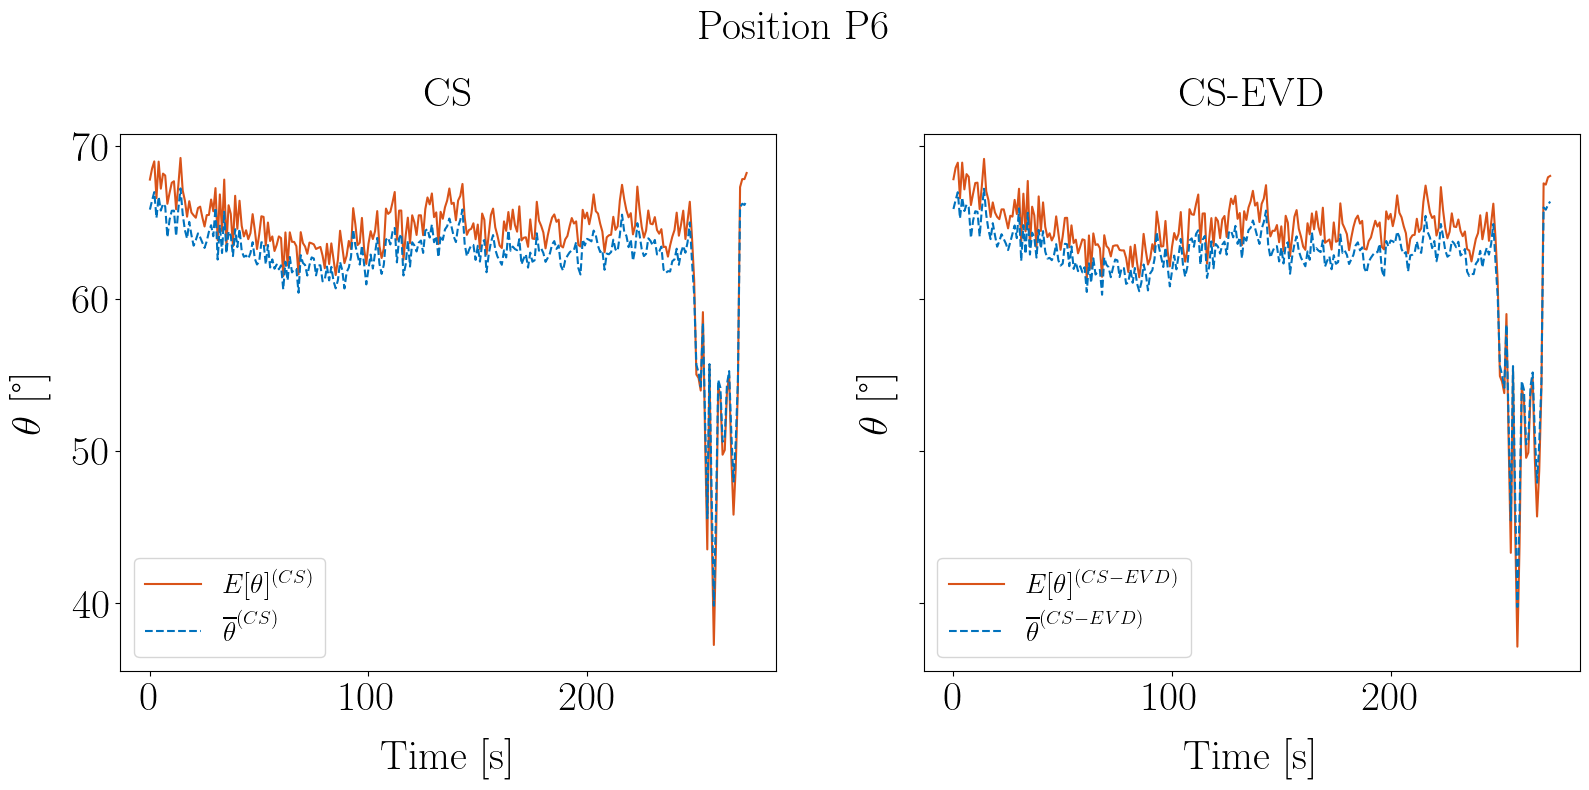

In [61]:
# idx_pos = 5
for idx_pos in [1, 4, 5]:
    fig, axs = plt.subplots(nrows=1, ncols=2, sharey=True)
    ax_cs, ax_cs_evd = axs
    # CS
    rtf_mfp_results["cs"]["expectation"].theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs,
        x="time",
        label=r"$E[\theta]^{(CS)}$",
        color=color(1),
        linestyle="-"
    )
    rtf_mfp_results["cs"]["mean"].theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs, x="time", label=r"$\overline{\theta}^{(CS)}$", color=color(0), linestyle="--"
    )
    ax_cs.set_title("CS")
    ax_cs.legend()

    # CS-EVD
    rtf_mfp_results["cs-evd"]["expectation"].theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs_evd,
        x="time",
        label=r"$E[\theta]^{(CS-EVD)}$",
        color=color(1),
        linestyle="-",
    )
    rtf_mfp_results["cs-evd"]["mean"].theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs_evd,
        x="time",
        label=r"$\overline{\theta}^{(CS-EVD)}$",
        color=color(0), 
        linestyle="--"
    )
    ax_cs_evd.set_title("CS-EVD")
    ax_cs_evd.legend()
    # plt.legend()

    fig.suptitle(f"Position P{idx_pos+1}")

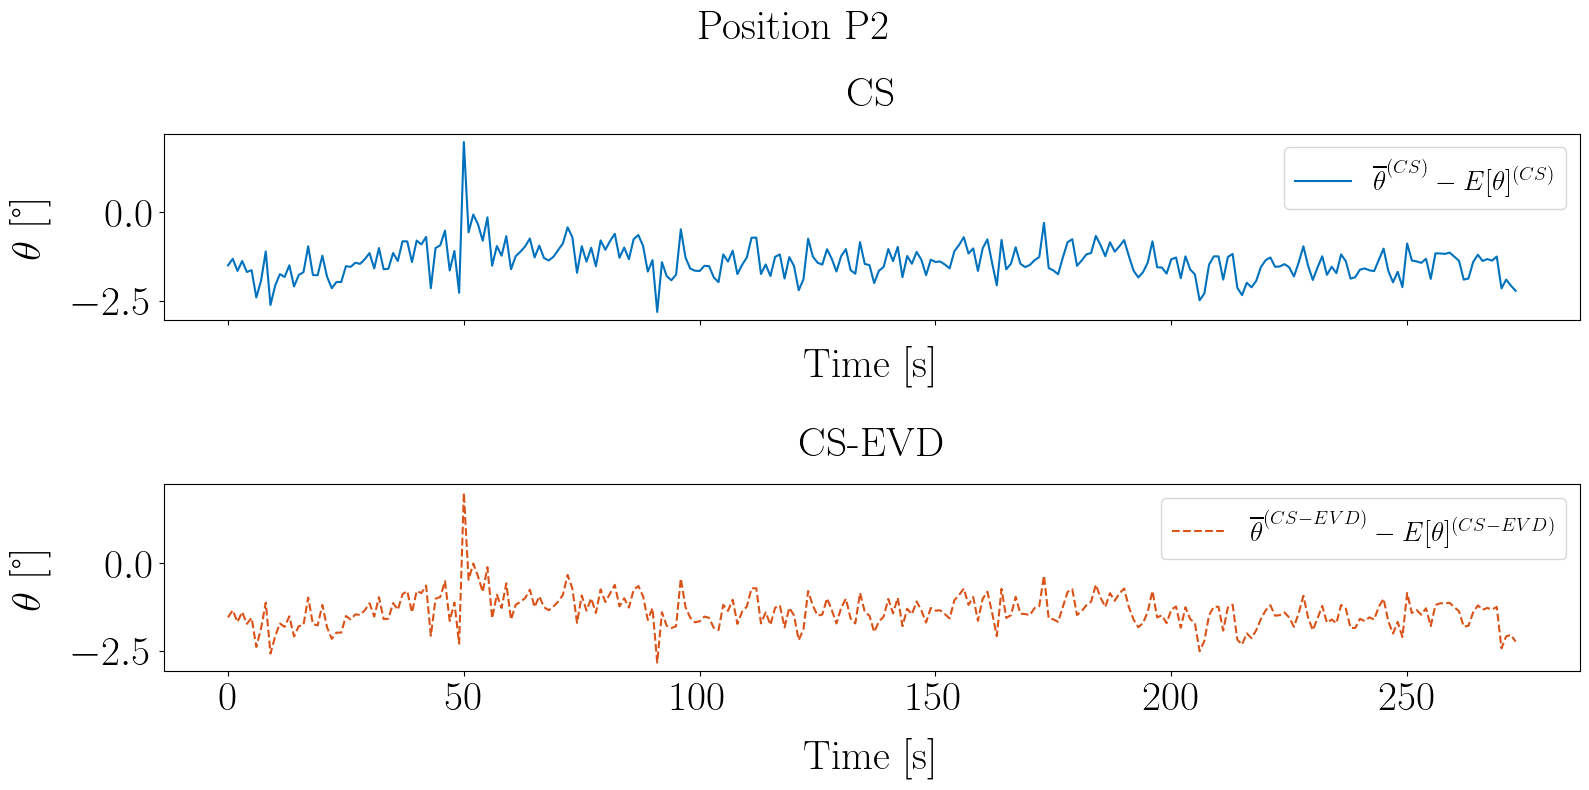

In [62]:
for idx_pos in [1]:
    fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
    ax_cs, ax_cs_evd = axs.flatten()
    delta_csbar_csexp.theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs,
        x="time",
        label=r"$\overline{\theta}^{(CS)} - E[\theta]^{(CS)}$",
        color=color(0),
        linestyle="-",
    )
    ax_cs.set_title("CS")
    ax_cs.legend()

    delta_cs_evdbar_cs_evdexp.theta.sel(idx_ref_position=idx_pos).plot(
        ax=ax_cs_evd,
        x="time",
        label=r"$\overline{\theta}^{(CS-EVD)} - E[\theta]^{(CS-EVD)}$",
        color=color(1),
        linestyle="--",
    )
    ax_cs_evd.set_title("CS-EVD")
    ax_cs_evd.legend()

    fig.suptitle(f"Position P{idx_pos+1}")

### Commentaires 

Comme dit précédemment, l'utilisation de l'espérance de la distribution permet d'améliorer le contraste de la surface d'ambiguïté. Ce gain de contraste est de l'ordre de 5°. 

Il faut toutefois noter que l'utilisation de l'espérance de la distribution nécessite une étape d'estimation de la densité de probabilité de la distribution, étape qui augmente considérablement le temps de calcul total. 

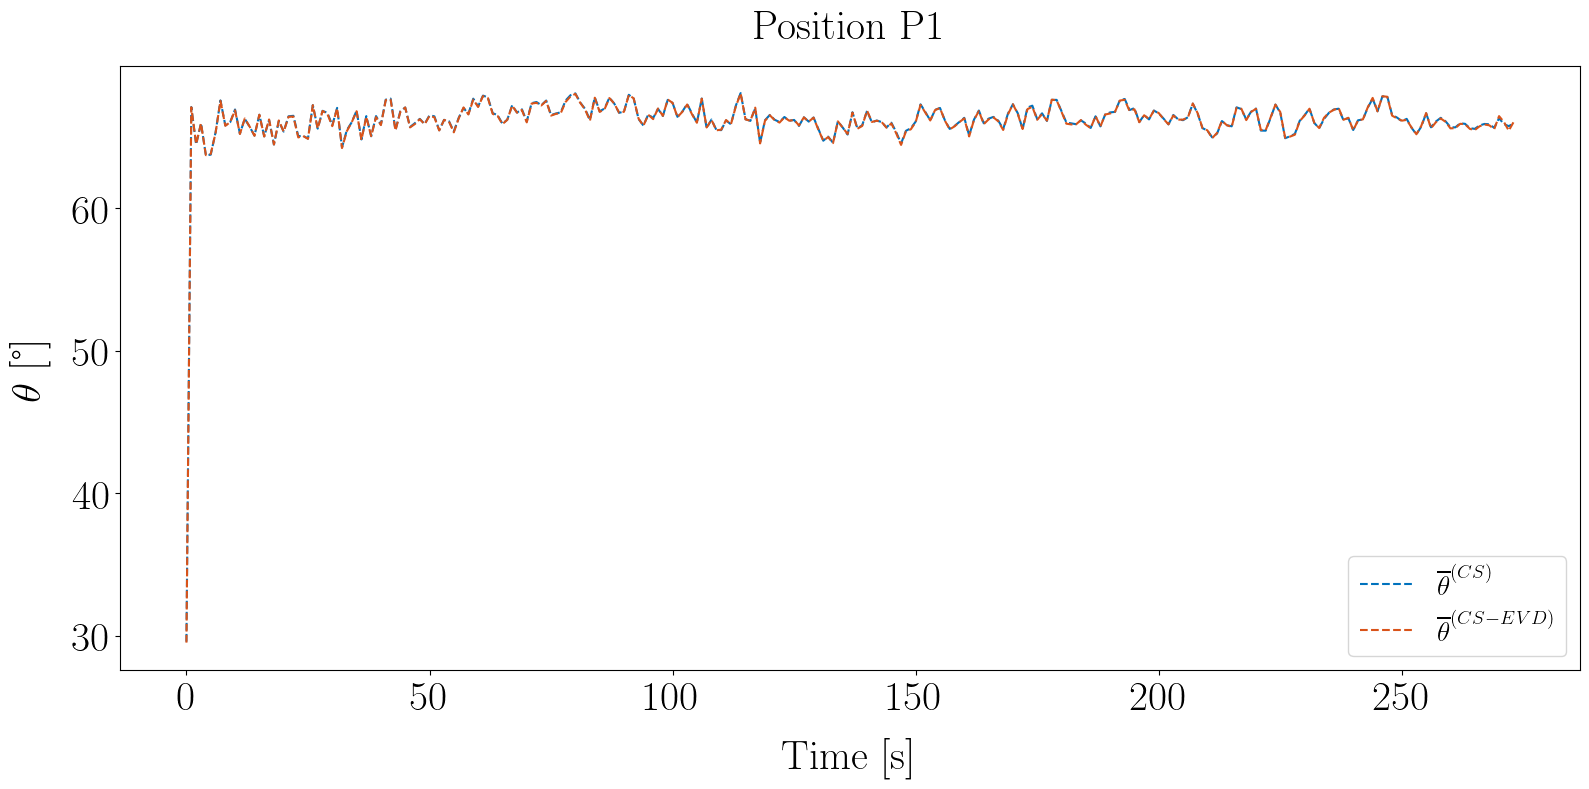

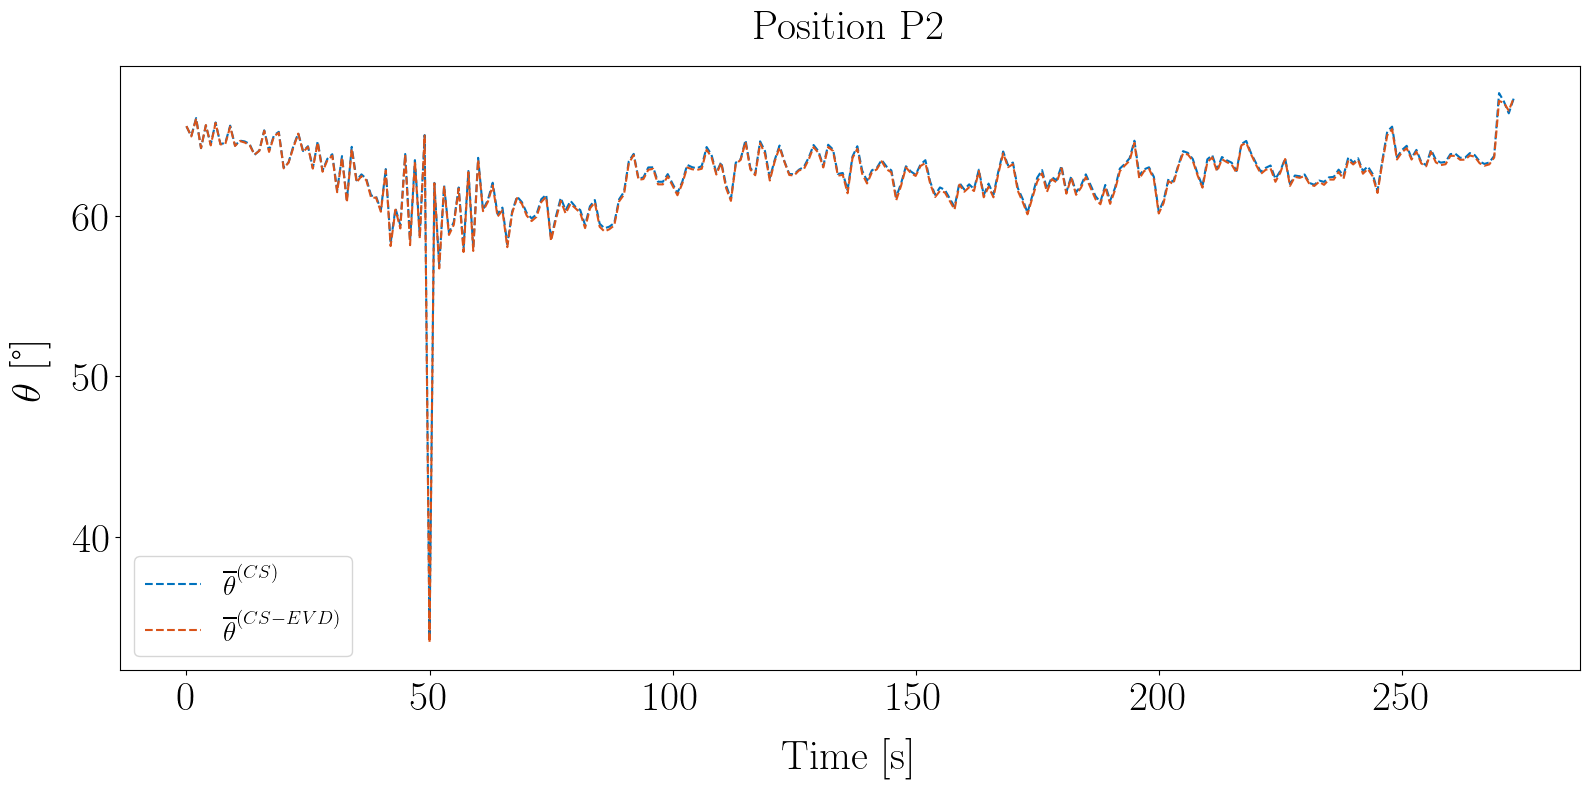

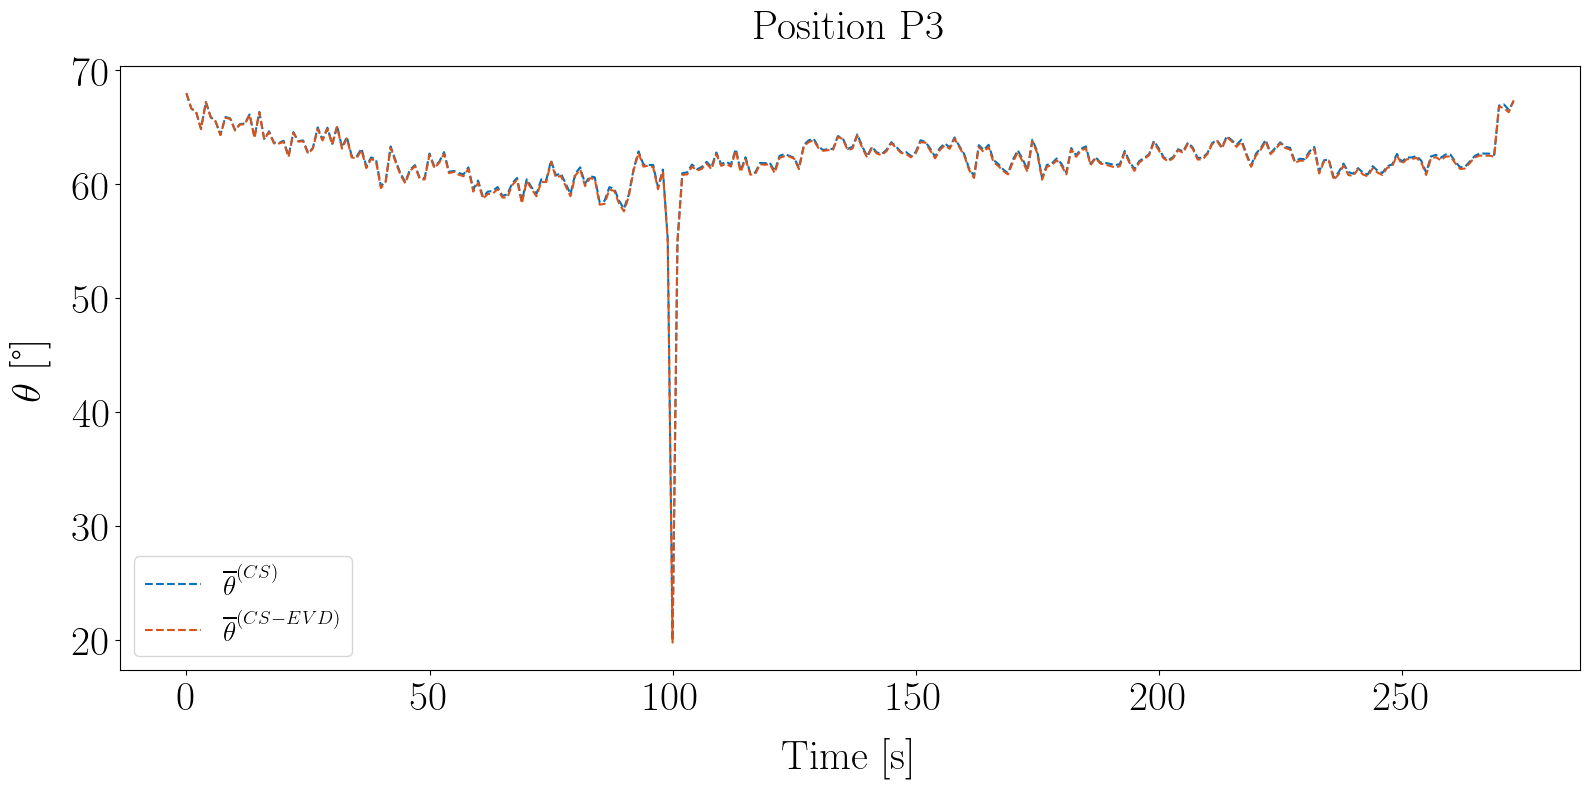

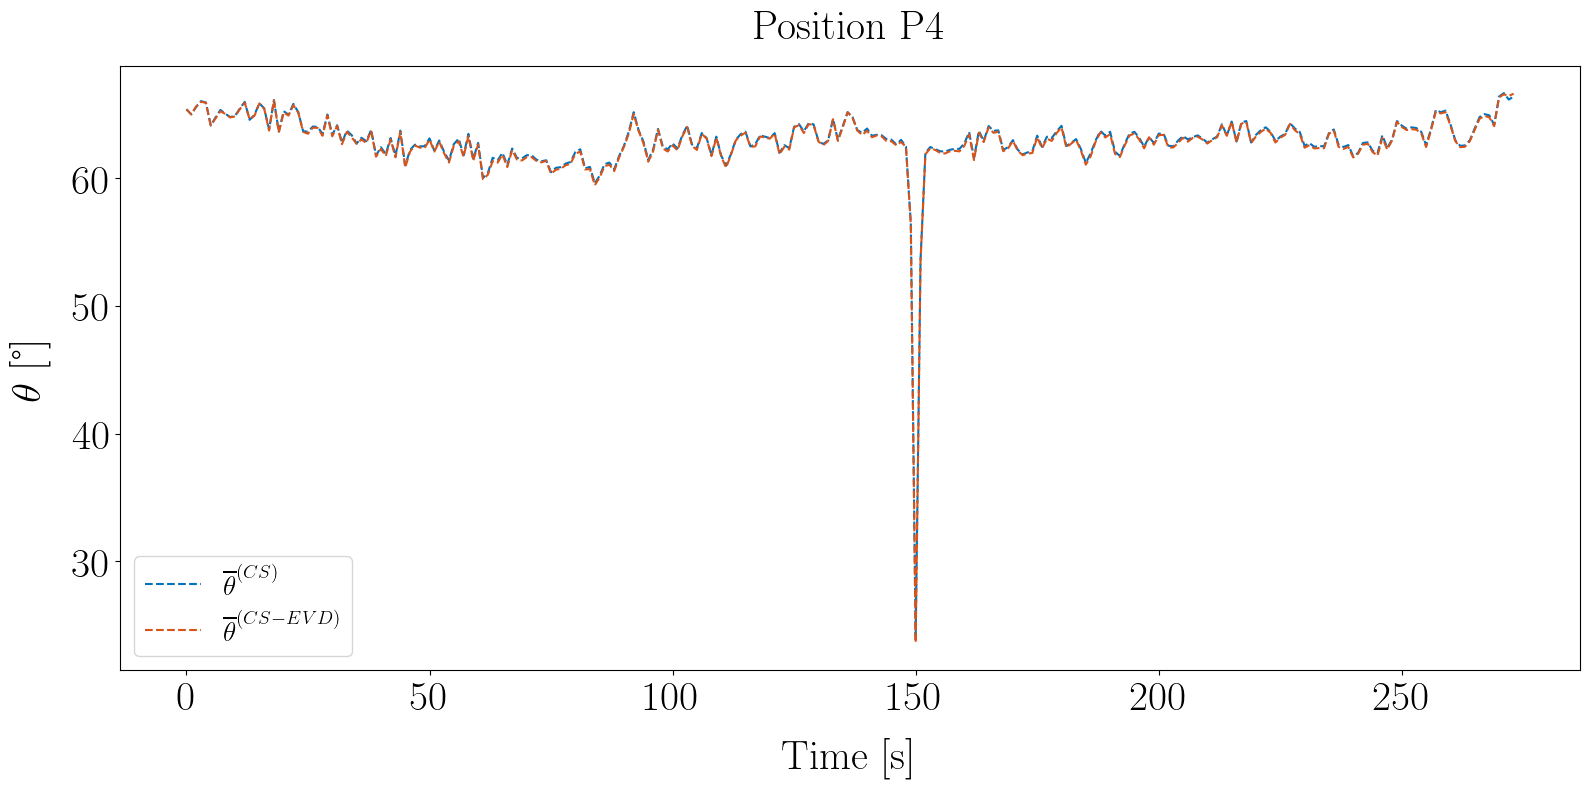

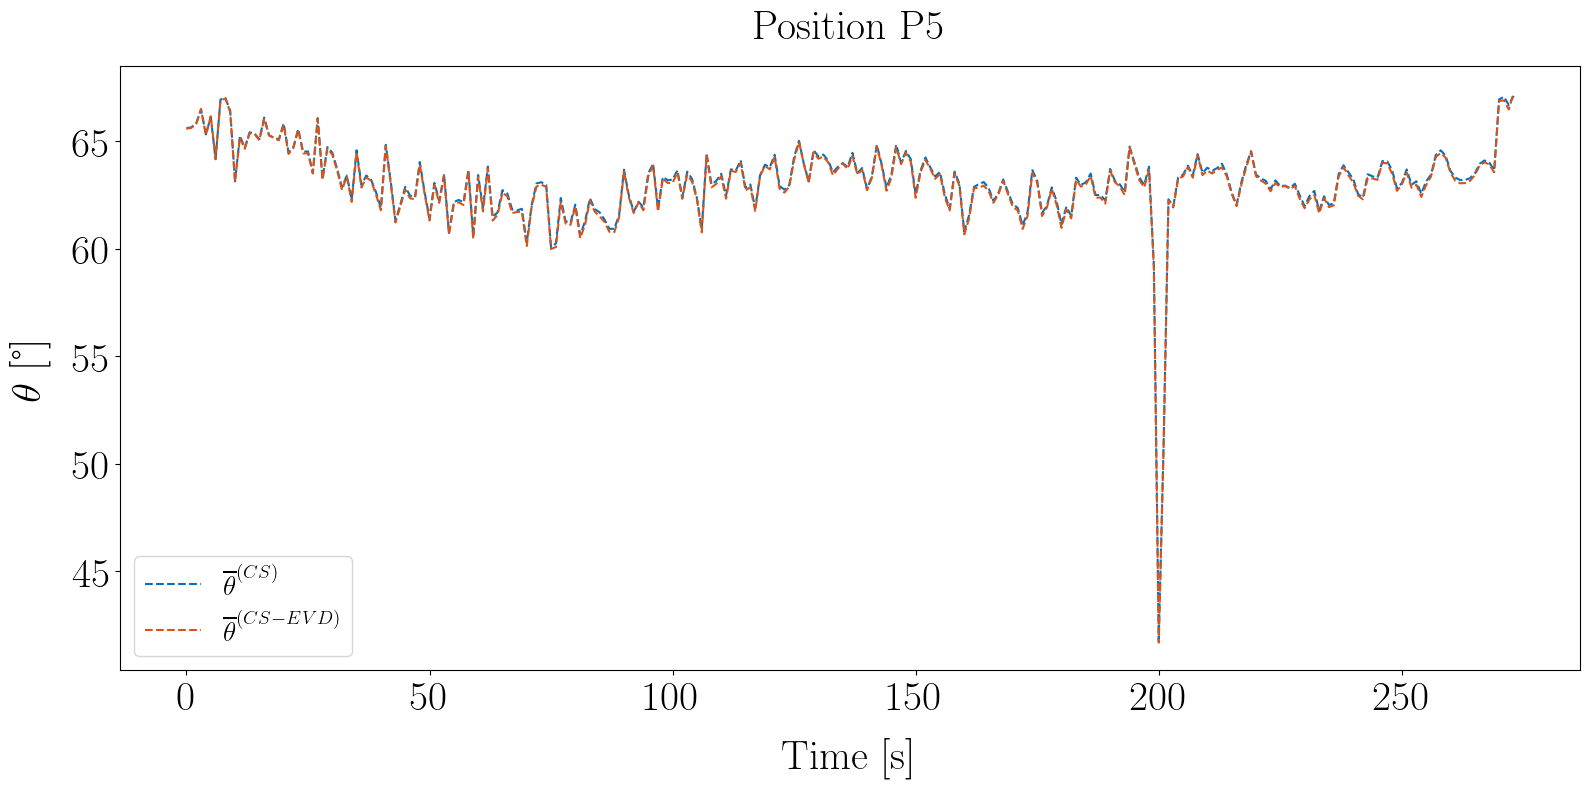

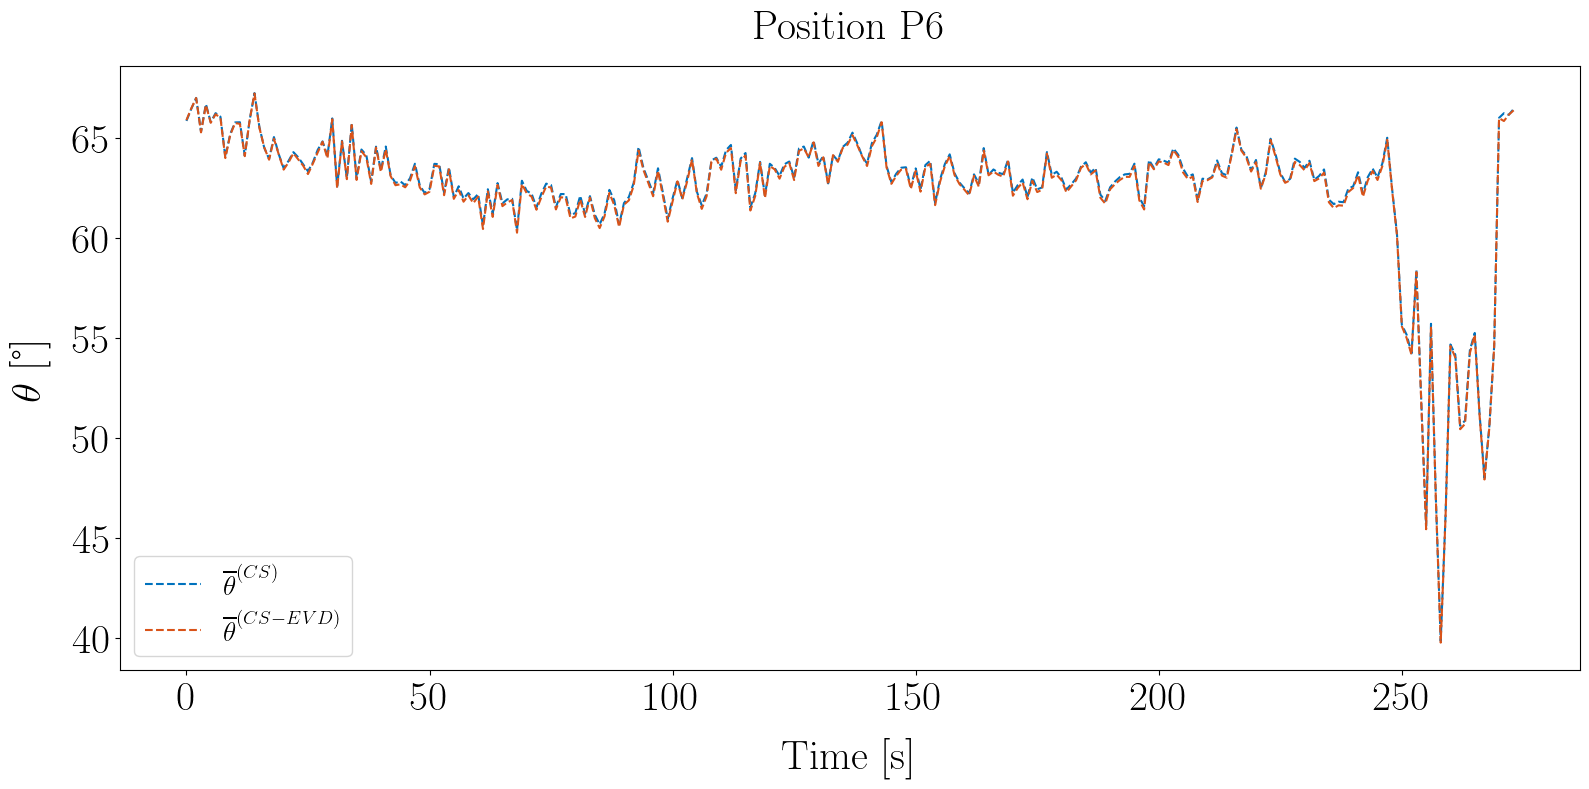

In [63]:
# idx_pos = 5
theta_stat = "mean"
for idx_pos in [0,1,2, 3, 4, 5]:
    plt.figure()
    # CS
    rtf_mfp_results["cs"][theta_stat].theta.sel(idx_ref_position=idx_pos).plot(
        # ax=ax_cs,
        x="time",
        label=r"$\overline{\theta}^{(CS)}$",
        color=color(0),
        linestyle="--",
    )

    # CS-EVD
    rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).plot(
        # ax=ax_cs_evd,
        x="time",
        label=r"$\overline{\theta}^{(CS-EVD)}$",
        color=color(1),
        linestyle="--",
    )

    plt.title(f"Position P{idx_pos+1}")
    # plt.ylim(20, 40)
    plt.legend()

### Commentaires 

Les deux estimateurs performent identiquement ce qui est attendu compte tenu du SNR très élevé. 

Cette dernière représentation permet d'apprécier plus facilement le contraste très important au passage de la position de référence. Ce contraste est de près de 40° dans le cas de la position P3. 

## La similitude des vecteurs de RTFs à la position correspondante est-elle appréciable visuellement ? 

On s'intéresse au cas de la position P3 (nommée dans les essais P2 (d=10m)) qui présente un très fort contraste. 

In [64]:
dict_th_pos

{'P1': 0, 'P2': 10, 'P3': 20, 'P4': 25, 'P5': 15, 'P6': 5}

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\xarray\core\dataarray.py:6285: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmin(dim, axis, keep_attrs, skipna)


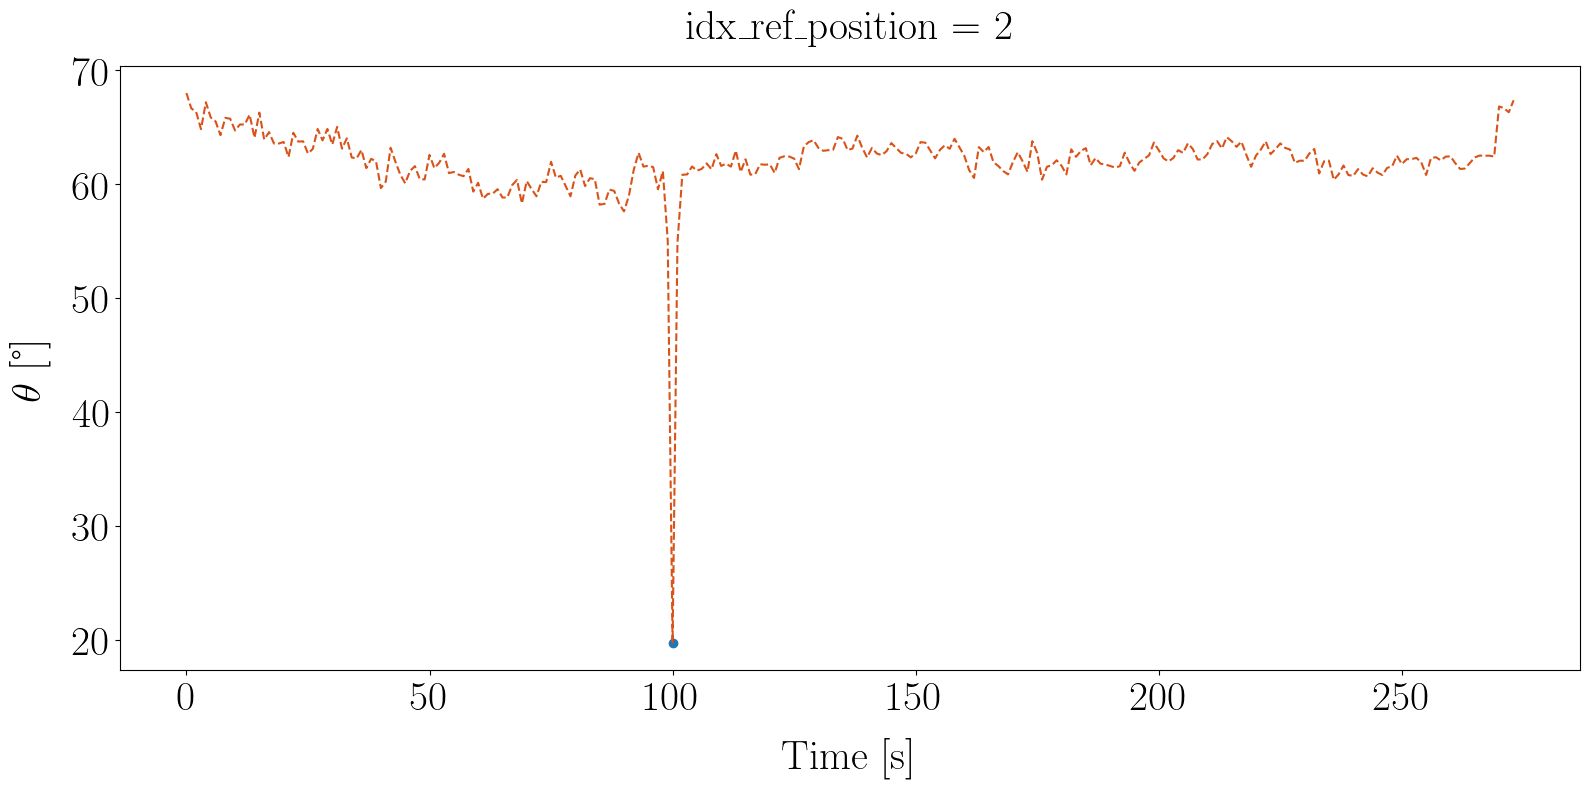

In [65]:
# Get the index of snapshot corresponding to the minimum theta :
idx_pos = 2
pos = "P2"
idx_snapshot = rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).argmin().values
theta_min = rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).values[idx_snapshot]
t_snapshot = rtf_mfp_results["cs-evd"][theta_stat].time.values[idx_snapshot]

# We can plot both to ensure its is the min
plt.figure()
rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).plot(
    # ax=ax_cs_evd,
    x="time",
    label=r"$\overline{\theta}^{(CS-EVD)}$",
    color=color(1),
    linestyle="--",
)
plt.scatter(t_snapshot, theta_min)
# plt.title(pos)

In [66]:
# Now we can load both files for static and dynamic containing RTF vectors
fpath_stat = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\static_to_loc\09-10-2024T16-51-22-900122_P2_N1_Sweep_93_rtf.nc"
rtf_stat = xr.open_dataset(fpath_stat)

root_dyn_files = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\dynamic_1pulses"
dyn_files = os.listdir(root_dyn_files) 
rtf_dyn_files = [f for f in dyn_files if "rtf" in f]

# Sort files by distance
rdist = [float(f.split("_r")[1].split("m")[0]) for f in rtf_dyn_files]
idx_rdist_sort = np.argsort(rdist)
rtf_dyn_files = [rtf_dyn_files[i] for i in idx_rdist_sort]

fpath_dyn = os.path.join(root_dyn_files, rtf_dyn_files[idx_snapshot])
rtf_dyn = xr.open_dataset(fpath_dyn)


print(f"P2(orginal label) (d={dict_th_pos['P2']}) ->  {rtf_dyn_files[idx_snapshot]}")

P2(orginal label) (d=10) ->  10-10-2024T16-53-43-200271_PR_N1_346_P1_r10.05m_P4_rtf.nc


In [67]:
# On peut calculer l'angle entre les deux vecteurs pour s'assurer que la représentation représente bien les vecteurs correspondant au minimum des thetas
rtf_stat_ = rtf_stat.rtf_amp_hat * np.exp(1j * rtf_stat.rtf_phase_hat)
rtf_dyn_ = rtf_dyn.rtf_amp_hat * np.exp(1j * rtf_dyn.rtf_phase_hat)


# We need to restrict to common freqs
rtf_stat_ = rtf_stat_.sel(f_rtf=rtf_dyn_.f_rtf.values)

dist_func = D_hermitian_angle_fast
ax_f = 1
ax_rcv = 0
dist_kwargs = {
    "ax_f": ax_f,
    "unit": "deg",
    "ax_rcv": ax_rcv,
    "apply_mean": True,
    "apply_median": False,
}

d = dist_func(rtf_stat_.values, rtf_dyn_.values, **dist_kwargs)
print(f"Distance dyn vs stat : {d}°")

Distance dyn vs stat : 19.734832598801702°


Text(0.5, 0, 'Frequency [Hz]')

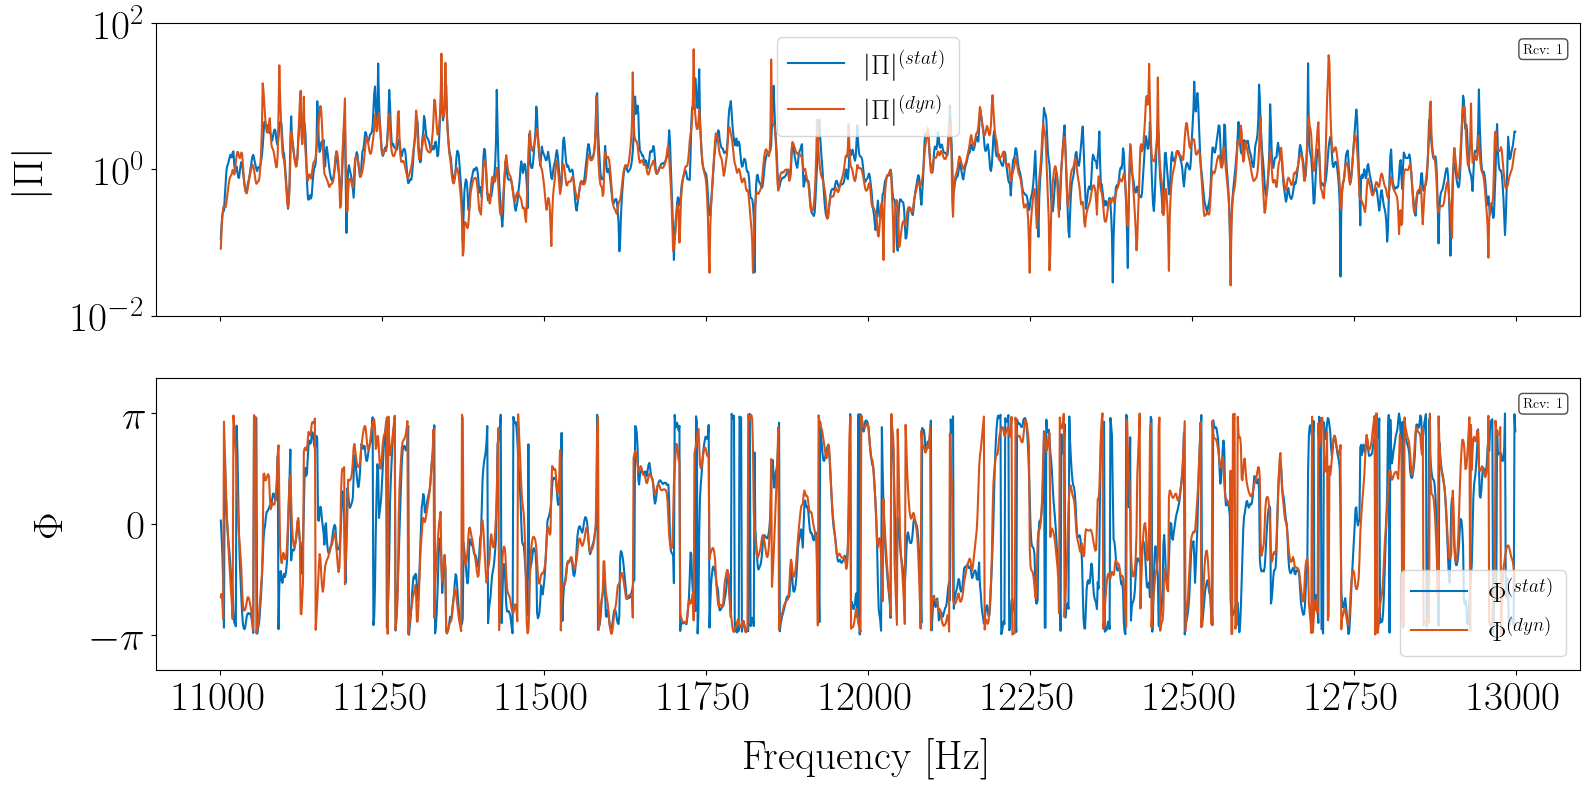

In [68]:
h_plot = 1
fmin = 11000
fmax = 13000
# Compare module and phase
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax_mod, ax_phase = axs

# Module
rtf_stat.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    ax=ax_mod, color=color(0), label=r"$|\Pi|^{(stat)}$"
)
rtf_dyn.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    ax=ax_mod, color=color(1), label=r"$|\Pi|^{(dyn)}$"
)
ax_mod.set_ylim([0.01, 100])
ax_mod.set_yscale("log")
ax_mod.set_xlabel("")
ax_mod.set_ylabel(r"$|\Pi|$")
ax_mod.set_title("")
ax_mod.legend()

# Add annotation for receiver index and record name
ax_mod.annotate(
    f"Rcv: {h_plot}",
    xy=(0.96, 0.9),
    xycoords="axes fraction",
    fontsize=10,
    color="black",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
)

# Phase
rtf_stat.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    ax=ax_phase, color=color(0), label=r"$\Phi^{(stat)}$"
)
rtf_dyn.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    ax=ax_phase, color=color(1), label=r"$\Phi^{(dyn)}$"
)

ax_phase.set_xlabel("")
ax_phase.set_ylabel(r"$\Phi$")
ax_phase.set_title("")
ax_phase.set_ylim(-np.pi - 1, np.pi + 1)
# Set yticks annotated in multiples of pi
ax_phase.set_yticks([-np.pi, 0, np.pi])
ax_phase.set_yticklabels(
    [r"$-\pi$", "0", r"$\pi$"]
)
ax_phase.legend()

ax_phase.annotate(
    f"Rcv: {h_plot}",
    xy=(0.96, 0.9),
    xycoords="axes fraction",
    fontsize=10,
    color="black",
    bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
)
plt.xlabel("Frequency [Hz]")

### Commentaires 

Cette représentation permet d'observer la bonne correspondance des vecteurs de RTFs. 

In [69]:

root_dyn_files = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\dynamic_1pulses"
dyn_files = os.listdir(root_dyn_files)
rtf_dyn_files = [f for f in dyn_files if "rtf" in f]

# Sort files by distance
rdist = [float(f.split("_r")[1].split("m")[0]) for f in rtf_dyn_files]
idx_rdist_sort = np.argsort(rdist)
rtf_dyn_files = [rtf_dyn_files[i] for i in idx_rdist_sort]


fpath_dyn = os.path.join(root_dyn_files, rtf_dyn_files[idx_snapshot])
rtf_dyn = xr.open_dataset(fpath_dyn)

# Build module matrix 
mod_mat = []
phi_mat = []
for file in rtf_dyn_files:
    fpath_dyn = os.path.join(root_dyn_files, file)
    rtf_dyn_i = xr.open_dataset(fpath_dyn)

    mod_mat.append(rtf_dyn_i.rtf_amp_hat.values)
    phi_mat.append(rtf_dyn_i.rtf_phase_hat.values)

mod_mat = np.array(mod_mat)
phi_mat = np.array(phi_mat)


In [70]:
mod_mat.shape # -> (npos, nrcv, nf)

(274, 5, 2458)

In [71]:

rtf_dyn_all = xr.Dataset(
    data_vars=dict(
        rtf_amp=(["replica_id", "h_index", "f_rtf"], mod_mat),
        rtf_phase=(["replica_id", "h_index", "f_rtf"], phi_mat),
    ),
    coords=dict(
        replica_id=np.arange(mod_mat.shape[0]), 
        h_index = rtf_dyn.h_index.values,
        f_rtf = rtf_dyn.f_rtf.values,
    )
)

C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_16564\4152617158.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_mod.legend()
C:\Users\baptiste.menetrier\AppData\Local\Temp\ipykernel_16564\4152617158.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_phase.legend()


(90.0, 110.0)

c:\Users\baptiste.menetrier\.virtualenvs\phd-FBjz4hBd\Lib\site-packages\IPython\core\events.py:96: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


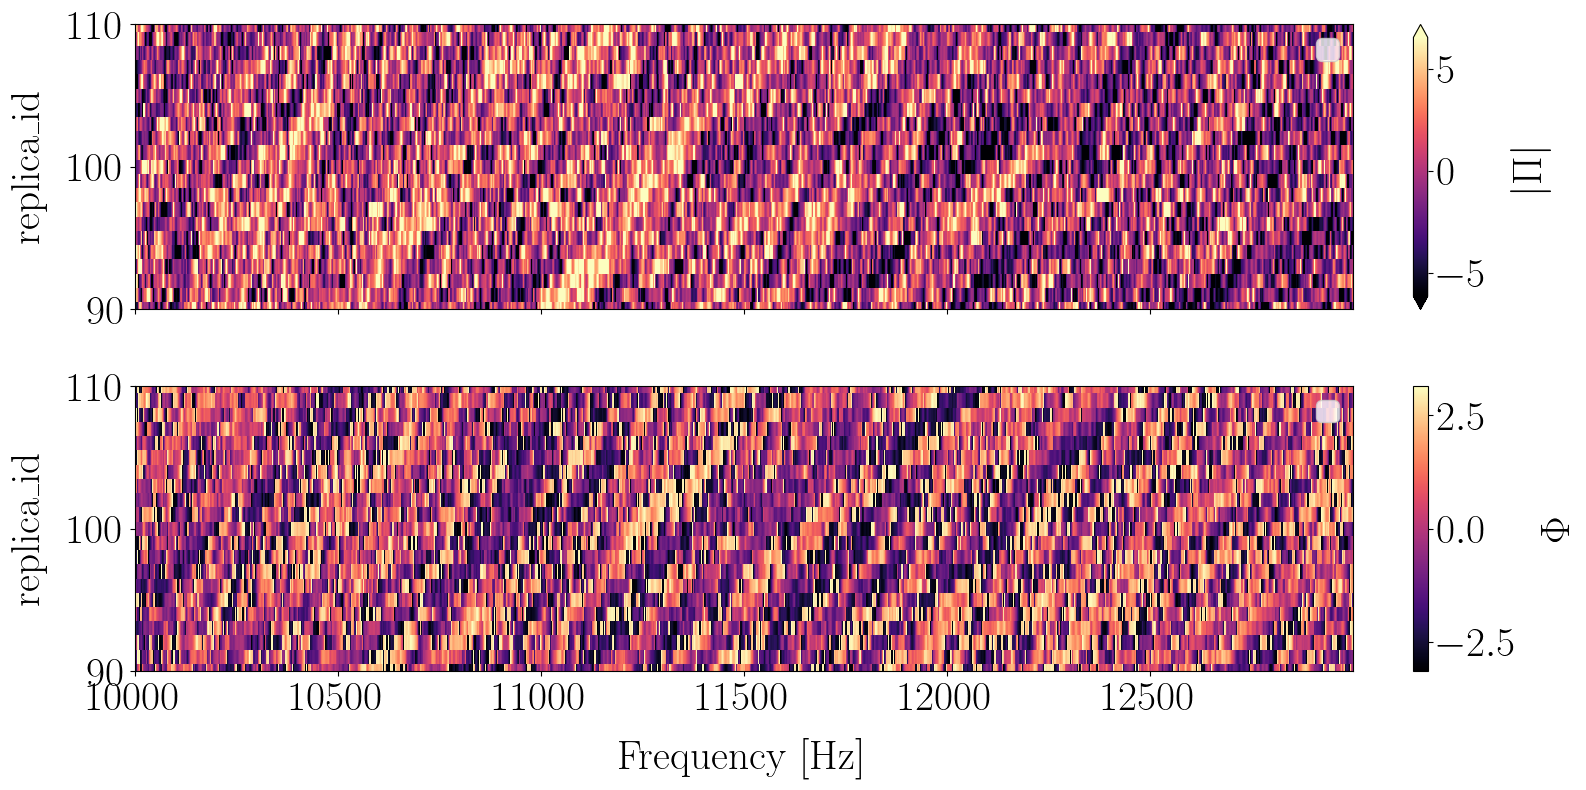

In [74]:
h_plot = 1
fmin = 10000
fmax = 13000
# Compare module and phase
fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)
ax_mod, ax_phase = axs

# Module
log_mod = 10*np.log10(rtf_dyn_all.rtf_amp.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)))
log_mod.plot(
    x="f_rtf",
    ax=ax_mod,
    cmap="magma",
    cbar_kwargs={"label": r"$\lvert \Pi \rvert$"},
    vmin=np.percentile(log_mod, 5),
    vmax=np.percentile(log_mod, 95),
    # color=color(1), label=r"$|\Pi|^{(dyn)}$"
)
# ax_mod.set_ylim([0.01, 100])
# ax_mod.set_yscale("log")
ax_mod.set_xlabel("")
# ax_mod.set_ylabel(r"$|\Pi|$")
ax_mod.set_title("")
ax_mod.legend()

# # Add annotation for receiver index and record name
# ax_mod.annotate(
#     f"Rcv: {h_plot}",
#     xy=(0.96, 0.9),
#     xycoords="axes fraction",
#     fontsize=10,
#     color="black",
#     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
# )

# Phase
rtf_dyn_all.rtf_phase.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    x="f_rtf", ax=ax_phase, cmap="magma", cbar_kwargs={"label": r"$\Phi$"}
    # color=color(1), label=r"$\Phi^{(dyn)}$"
)

ax_phase.set_xlabel("")
# ax_phase.set_ylabel(r"$\Phi$")
ax_phase.set_title("")
# ax_phase.set_ylim(-np.pi - 1, np.pi + 1)
# Set yticks annotated in multiples of pi
# ax_phase.set_yticks([-np.pi, 0, np.pi])
# ax_phase.set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
ax_phase.legend()

# ax_phase.annotate(
#     f"Rcv: {h_plot}",
#     xy=(0.96, 0.9),
#     xycoords="axes fraction",
#     fontsize=10,
#     color="black",
#     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
# )
plt.xlabel("Frequency [Hz]")
ax_mod.set_ylim([90, 110])
ax_phase.set_ylim([90, 110])

# Figure pour le papier JASA EL 

Pour le papier on conserve la surface d'ambiguïté obtenue avec la méthode CS-EVD et la moyenne empirique comme grandeur caractéristique de la distribution des $\theta$. 

In [ ]:
# Plot q_dB
jasa_el_map = rtf_mfp_results["cs-evd"]["mean"]

from publication.publication_figure import PubFigure
# pfig = PubFigure()

# Paramètres utilisés pour les autres figures (cas test Zhang et al 2023)
pfig = PubFigure(
    label_fontsize=27,
    ticks_fontsize=25,
    labelpad=15,
    legend_fontsize=18,
    title_fontsize=14,
)

# Update longname to math style for publication
jasa_el_map.q_dB.attrs["long_name"] = r"$q$"

f, ax = plt.subplots(1, 1, figsize=(12, 6))
jasa_el_map.q_dB.plot(x="time", cmap="jet", vmin=-5, rasterized=True, ax=ax, extend="neither")

# Change y axis labels for position
ordered_pos = [f"$P_{i}$" for i in range(1, 7)]
plt.yticks(np.arange(0, 6), ordered_pos)
plt.ylabel("Position")

# Save
# fpath = os.path.join(root_img, "figure_4b.eps")
# plt.savefig(fpath, dpi=300)
# fpath = os.path.join(root_img, "figure_4b.ps")
# plt.savefig(fpath, dpi=300)
fpath = os.path.join(root_img, "figure_4b.pdf")
plt.savefig(fpath, dpi=600)
fpath = os.path.join(root_img, "rtf_mfp_surf_jasa_el.png")
plt.savefig(fpath, dpi=300)

# Réponse aux reviewers



## Utilité de la colomap jet pour la figure : figure en nuances de gris

**Reviewer 3:**
" Color not needed for figure 4. "

L'un des reviewers suggère que l'utilisation de couleurs est inutile pour cette figure. On peut reproduire la figure en nuances de gris pour comparaison. 



In [ ]:
# Plot q_dB
jasa_el_map = rtf_mfp_results["cs-evd"]["mean"]

# Paramètres utilisés pour les autres figures (cas test Zhang et al 2023)
pfig = PubFigure(
    label_fontsize=27,
    ticks_fontsize=25,
    labelpad=15,
    legend_fontsize=18,
    title_fontsize=14,
)

# Update longname to math style for publication
jasa_el_map.q_dB.attrs["long_name"] = r"$q$"

f, ax = plt.subplots(1, 1, figsize=(12, 6))
jasa_el_map.q_dB.plot(x="time", cmap="Greys", vmin=-5, rasterized=True, ax=ax, extend="neither")

# Change y axis labels for position
ordered_pos = [f"$P_{i}$" for i in range(1, 7)]
plt.yticks(np.arange(0, 6), ordered_pos)
plt.ylabel("Position")

# Save
# fpath = os.path.join(root_img, "figure_4b.eps")
# plt.savefig(fpath, dpi=300)
# fpath = os.path.join(root_img, "figure_4b.ps")
# plt.savefig(fpath, dpi=300)
fpath = os.path.join(root_img, "figure_4b_greys.pdf")
plt.savefig(fpath, dpi=600)
fpath = os.path.join(root_img, "rtf_mfp_surf_jasa_el_greys.png")
plt.savefig(fpath, dpi=300)

La représentation est bien adaptée et permet d'apprécier plus facilement le contraste. 

## Encodage de l'information de position dans le vecteur de RTF 

**Reviewer 3:**
" Paragraph starting with line 210. I suggest the authors consider showing example plots of RTFs to help the reader understand how source position is encoded in them. "

L'ensemble des papiers qui traitent de localisation à l'aide des RTFs ne représentent pas les RTFs directement. Les fonctions de transfert du guide d'onde encodent par nature la position de la source, les RTFs, définies comme le rapport des fonctions de transfert, conservent cette information. 

A titre didactique on peut tout de même comparer les vecteurs de RTFs : 

* A une position Pi pour l'enregistrement en statique
* A la même position Pi pour l'enregistrement dynamique 
* A une position distincte pour l'enregistrement dynamique 

La représentation la plus parlante est celle du module des RTFs, bien que l'interprétation de la structure des RTFs en fréquences ne soit pas évidente. On pourra également éventuellement représenter la phase déroulée de chacune des composantes.  



In [ ]:
dict_th_pos

In [ ]:
# Get the index of snapshot corresponding to the minimum theta :
idx_pos = 2
pos = "P2"
pos_label = "P3"
idx_snapshot = rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).argmin().values
theta_min = rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).values[idx_snapshot]
t_snapshot = rtf_mfp_results["cs-evd"][theta_stat].time.values[idx_snapshot]


idx_snapshot_bad_agreement = idx_snapshot + 1
theta_bad_agreement = rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).values[idx_snapshot_bad_agreement]
t_snapshot_bad_agreement = rtf_mfp_results["cs-evd"][theta_stat].time.values[idx_snapshot_bad_agreement]

# We can plot both to ensure its is the min
plt.figure()
rtf_mfp_results["cs-evd"][theta_stat].theta.sel(idx_ref_position=idx_pos).plot(
    # ax=ax_cs_evd,
    x="time",
    label=r"$\overline{\theta}^{(CS-EVD)}$",
    color=color(1),
    linestyle="--",
)
# Add markers for both the snapshot with minimum theta and the one with bad agreement
plt.scatter(t_snapshot, theta_min, color="k")
plt.scatter(t_snapshot_bad_agreement, theta_bad_agreement, color="r")
# plt.title(pos)

print(f"Theta at pos : {theta_min:.1f}°")
print(f"Theta at next pos : {theta_bad_agreement:.1f}°  ")

In [ ]:
# Now we can load both files for static and dynamic containing RTF vectors
fpath_stat = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\static_to_loc\09-10-2024T16-51-22-900122_P2_N1_Sweep_93_rtf.nc"
rtf_stat = xr.open_dataset(fpath_stat)

root_dyn_files = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\dynamic_1pulses"
dyn_files = os.listdir(root_dyn_files) 
rtf_dyn_files = [f for f in dyn_files if "rtf" in f]

# Sort files by distance
rdist = [float(f.split("_r")[1].split("m")[0]) for f in rtf_dyn_files]
idx_rdist_sort = np.argsort(rdist)
rtf_dyn_files = [rtf_dyn_files[i] for i in idx_rdist_sort]

fpath_dyn = os.path.join(root_dyn_files, rtf_dyn_files[idx_snapshot])
rtf_dyn = xr.open_dataset(fpath_dyn)

rtf_dyn_bad_agreement = xr.open_dataset(os.path.join(root_dyn_files, rtf_dyn_files[idx_snapshot_bad_agreement]))


print(f"P2(orginal label) (d={dict_th_pos['P2']}) ->  {rtf_dyn_files[idx_snapshot]}")

In [ ]:
fmin = 11300
fmax = 11700

n_rcv = rtf_stat.h_index.size
# Compare module and phase
# fig, axs = plt.subplots(nrows=2, ncols=n_rcv, sharex=True, sharey="row")
# ax_mod, ax_phase = axs[0, :], axs[1, :]

fig, axs = plt.subplots(nrows=n_rcv, ncols=2, sharex=True, figsize=(16, 3*n_rcv))
ax_mod, ax_phase = axs[:,  0], axs[:, 1]

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    # Module
    rtf_stat.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv], color="k", label=r"$\Pi^{(static)}$"
    )
    rtf_dyn.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color=color(0),
        label=r"$\Pi^{(dynamic)}(t = t_{P_2})$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )
    rtf_dyn_bad_agreement.rtf_amp_hat.sel(h_index=h_plot).sel(
        f_rtf=slice(fmin, fmax)
    ).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        label=r"$\Pi^{(dynamic)}(t = t_{P_2} + \Delta t)$",
        marker="x",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )
    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$|\Pi|$")
    # ax_mod[i_rcv].set_ylabel("")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")

    # # Add annotation for receiver index and record name
    # ax_mod[i_rcv].annotate(
    #     f"Rcv: {h_plot}",
    #     xy=(0.96, 0.9),
    #     xycoords="axes fraction",
    #     fontsize=10,
    #     color="black",
    #     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    # )

    # # Phase
    # rtf_stat.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    #     ax=ax_phase[i_rcv], color="k", label=r"$\Phi^{(stat)}$"
    # )
    # rtf_dyn.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    #     ax=ax_phase[i_rcv],
    #     color=color(0),
    #     label=r"$\Phi^{(dyn)}$",
    #     marker="o",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )
    # rtf_dyn_bad_agreement.rtf_phase_hat.sel(h_index=h_plot).sel(
    #     f_rtf=slice(fmin, fmax)
    # ).plot(
    #     ax=ax_phase[i_rcv],
    #     color=color(1),
    #     label=r"$\Phi^{(dyn)}$",
    #     marker="x",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )

    # ax_phase[i_rcv].set_xlabel("")
    # ax_phase[i_rcv].set_ylabel(r"$\Phi$")
    # ax_phase[i_rcv].set_title("")
    # # Set yticks annotated in multiples of pi
    # ax_phase[i_rcv].set_yticks([-np.pi, 0, np.pi])
    # ax_phase[i_rcv].set_yticklabels([r"$-\pi$", "0", r"$\pi$"])
    # # ax_phase[i_rcv].legend(fontsize=12, ncol=3, loc="upper right")

    # # ax_phase[i_rcv].annotate(
    # #     f"Rcv: {h_plot}",
    # #     xy=(0.96, 0.9),
    # #     xycoords="axes fraction",
    # #     fontsize=10,
    # #     color="black",
    # #     bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7),
    # # )

    # Unwrapped phase
    rtf_stat_i = rtf_stat.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    rtf_stat_unwrap = np.unwrap(rtf_stat_i)
    ax_phase[i_rcv].plot(
        rtf_stat_i.f_rtf,
        rtf_stat_unwrap,
        color="k",
        label=r"$\Pi^{(static)}$",
    )

    rtf_dyn_i = rtf_dyn.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    rtf_dyn_unwrap = np.unwrap(rtf_dyn_i)
    ax_phase[i_rcv].plot(
        rtf_dyn_i.f_rtf,
        rtf_dyn_unwrap,
        color=color(0),
        label=r"$\Pi^{(dynamic)}(t = t_{P_2})$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )

    rtf_dyn_bad_agreement_i = rtf_dyn_bad_agreement.rtf_phase_hat.sel(
        h_index=h_plot
    ).sel(f_rtf=slice(fmin, fmax))
    rtf_dyn_bad_agreement_unwrap = np.unwrap(rtf_dyn_bad_agreement_i)
    ax_phase[i_rcv].plot(
        rtf_dyn_bad_agreement_i.f_rtf,
        rtf_dyn_bad_agreement_unwrap,
        color=color(1),
        label=r"$\Pi^{(dynamic)}(t = t_{P_2} + \Delta t)$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )

    ax_phase[i_rcv].set_xlabel("")
    ax_phase[i_rcv].set_ylabel(r"$\Phi$")
    ax_phase[i_rcv].set_title("")
    ax_phase[i_rcv].set_ylim([-30, 30])
    ax_phase[i_rcv].legend(fontsize=10, ncol=3, loc="lower right")


ax_mod[0].set_title(r"$\Pi_{15} = \frac{H_1}{H_5}$", fontsize=18)
ax_mod[1].set_title(r"$\Pi_{25} = \frac{H_2}{H_5}$", fontsize=18)
ax_mod[2].set_title(r"$\Pi_{35} = \frac{H_3}{H_5}$", fontsize=18)
ax_mod[3].set_title(r"$\Pi_{45} = \frac{H_4}{H_5}$", fontsize=18)
ax_mod[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

ax_phase[0].set_title(r"$\Pi_{15} = \frac{H_1}{H_5}$", fontsize=18)
ax_phase[1].set_title(r"$\Pi_{25} = \frac{H_2}{H_5}$", fontsize=18)
ax_phase[2].set_title(r"$\Pi_{35} = \frac{H_3}{H_5}$", fontsize=18)
ax_phase[3].set_title(r"$\Pi_{45} = \frac{H_4}{H_5}$", fontsize=18)
ax_phase[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

set_subfigures_abc_labels(axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top")

# plt.xlabel("Frequency [Hz]")
fig.supxlabel("Frequency [Hz]")

fig.suptitle(
    f"Comparison of RTF vectors for position {pos_label}",
    fontsize=30,
)

# Save
fpath = os.path.join(root_img, "rtf_mfp_jasa_el_source_pos_encoding_info_illustration.png")
plt.savefig(fpath, dpi=300)

### Version en deux figures (suggestion de Valérie)

In [ ]:
fmin = 11300
fmax = 11700

n_rcv = rtf_stat.h_index.size - 1
# Compare module and phase
# fig, axs = plt.subplots(nrows=2, ncols=n_rcv, sharex=True, sharey="row")
# ax_mod, ax_phase = axs[0, :], axs[1, :]

fig, axs = plt.subplots(nrows=n_rcv, ncols=2, sharex=True, figsize=(16, 3*n_rcv))
ax_mod, ax_phase = axs[:,  0], axs[:, 1]

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    # Module
    rtf_stat.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color="k",
        # label=r"$\Pi^{(static)}$",
        # label=r"$\Pi^{(library)}$",
        label="Library",
    )
    rtf_dyn.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color=color(0),
        # label=r"$\Pi^{(dynamic)}(t = t_{P_3})$",
        # label=r"$\Pi^{(event)}(t = t_{P_3})$",
        label=r"Event $(t = t_{P_3})$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )
    # rtf_dyn_bad_agreement.rtf_amp_hat.sel(h_index=h_plot).sel(
    #     f_rtf=slice(fmin, fmax)
    # ).plot(
    #     ax=ax_mod[i_rcv],
    #     color=color(1),
    #     label=r"$\Pi^{(dynamic)}(t = t_{P_3} + \Delta t)$",
    #     marker="x",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )
    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$|\hat{\Pi}|$")
    # ax_mod[i_rcv].set_ylabel("")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=3, loc="lower left")

    # Unwrapped phase
    rtf_stat_i = rtf_stat.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    rtf_stat_unwrap = np.unwrap(rtf_stat_i)
    ax_phase[i_rcv].plot(
        rtf_stat_i.f_rtf,
        rtf_stat_unwrap,
        color="k",
        # label=r"$\Pi^{(static)}$",
        # label=r"$\Pi^{(library)}$",
        label="Library",
    )

    rtf_dyn_i = rtf_dyn.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    rtf_dyn_unwrap = np.unwrap(rtf_dyn_i)
    ax_phase[i_rcv].plot(
        rtf_dyn_i.f_rtf,
        rtf_dyn_unwrap,
        color=color(0),
        # label=r"$\Pi^{(dynamic)}(t = t_{P_3})$",
        # label=r"$\Pi^{(event)}(t = t_{P_3})$",
        label=r"Event $(t = t_{P_3})$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )

    # rtf_dyn_bad_agreement_i = rtf_dyn_bad_agreement.rtf_phase_hat.sel(
    #     h_index=h_plot
    # ).sel(f_rtf=slice(fmin, fmax))
    # rtf_dyn_bad_agreement_unwrap = np.unwrap(rtf_dyn_bad_agreement_i)
    # ax_phase[i_rcv].plot(
    #     rtf_dyn_bad_agreement_i.f_rtf,
    #     rtf_dyn_bad_agreement_unwrap,
    #     color=color(1),
    #     label=r"$\Pi^{(dynamic)}(t = t_{P_3} + \Delta t)$",
    #     marker="o",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )

    ax_phase[i_rcv].set_xlabel("")
    ax_phase[i_rcv].set_ylabel(r"$\hat{\Phi}$")
    ax_phase[i_rcv].set_title("")
    ax_phase[i_rcv].set_ylim([-30, 30])
    ax_phase[i_rcv].legend(fontsize=12, ncol=3, loc="lower left")


ax_mod[0].set_title(r"$\hat{\Pi}_{15} = \frac{h_1}{h_5}$", fontsize=20)
ax_mod[1].set_title(r"$\hat{\Pi}_{25} = \frac{h_2}{h_5}$", fontsize=20)
ax_mod[2].set_title(r"$\hat{\Pi}_{35} = \frac{h_3}{h_5}$", fontsize=20)
ax_mod[3].set_title(r"$\hat{\Pi}_{45} = \frac{h_4}{h_5}$", fontsize=20)
# ax_mod[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

ax_phase[0].set_title(r"$\hat{\Pi}_{15} = \frac{h_1}{h_5}$", fontsize=20)
ax_phase[1].set_title(r"$\hat{\Pi}_{25} = \frac{h_2}{h_5}$", fontsize=20)
ax_phase[2].set_title(r"$\hat{\Pi}_{35} = \frac{h_3}{h_5}$", fontsize=20)
ax_phase[3].set_title(r"$\hat{\Pi}_{45} = \frac{h_4}{h_5}$", fontsize=20)
# ax_phase[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

set_subfigures_abc_labels(axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top")

# plt.xlabel("Frequency [Hz]")
fig.supxlabel("Frequency [Hz]")

# fig.suptitle(
#     f"Comparison of RTF vectors for position {pos_label}",
#     fontsize=30,
# )

# Save
fpath = os.path.join(root_img, "rtf_mfp_jasa_el_source_pos_encoding_info_illustration_good_pos.png")
plt.savefig(fpath, dpi=300)

# Save
fpath = os.path.join(root_img, "figure_1.pdf")
plt.savefig(fpath, dpi=600)

In [ ]:
fig, axs = plt.subplots(nrows=n_rcv, ncols=2, sharex=True, figsize=(16, 3 * n_rcv))
ax_mod, ax_phase = axs[:, 0], axs[:, 1]

for i_rcv in range(n_rcv):
    h_plot = i_rcv + 1

    # Module
    rtf_stat.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
        ax=ax_mod[i_rcv],
        color="k",
        # label=r"$\Pi^{(static)}$",
        # label=r"$\Pi^{(library)}$",
        label="Library",
    )
    # rtf_dyn.rtf_amp_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax)).plot(
    #     ax=ax_mod[i_rcv],
    #     color=color(0),
    #     label=r"$\Pi^{(dynamic)}(t = t_{P_3})$",
    #     marker="o",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )
    rtf_dyn_bad_agreement.rtf_amp_hat.sel(h_index=h_plot).sel(
        f_rtf=slice(fmin, fmax)
    ).plot(
        ax=ax_mod[i_rcv],
        color=color(1),
        # label=r"$\Pi^{(dynamic)}(t = t_{P_3} + \Delta t)$",
        # label=r"$\Pi^{(event)}(t = t_{P_3} + \Delta t)$",
        label=r"Event $(t = t_{P_3} + \Delta t)$",
        marker="x",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )
    ax_mod[i_rcv].set_ylim([0.01, 100])
    ax_mod[i_rcv].set_yscale("log")
    ax_mod[i_rcv].set_xlabel("")
    ax_mod[i_rcv].set_ylabel(r"$|\hat{\Pi}|$")
    # ax_mod[i_rcv].set_ylabel("")
    ax_mod[i_rcv].set_title("")
    ax_mod[i_rcv].legend(fontsize=12, ncol=3, loc="lower left")

    # Unwrapped phase
    rtf_stat_i = rtf_stat.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    rtf_stat_unwrap = np.unwrap(rtf_stat_i)
    ax_phase[i_rcv].plot(
        rtf_stat_i.f_rtf,
        rtf_stat_unwrap,
        color="k",
        # label=r"$\Pi^{(static)}$",
        # label=r"$\Pi^{(library)}$",
        label="Library",
    )

    # rtf_dyn_i = rtf_dyn.rtf_phase_hat.sel(h_index=h_plot).sel(f_rtf=slice(fmin, fmax))
    # rtf_dyn_unwrap = np.unwrap(rtf_dyn_i)
    # ax_phase[i_rcv].plot(
    #     rtf_dyn_i.f_rtf,
    #     rtf_dyn_unwrap,
    #     color=color(0),
    #     label=r"$\Pi^{(dynamic)}(t = t_{P_3})$",
    #     marker="o",
    #     linewidth=1,
    #     markersize=3,
    #     alpha=0.7,
    # )

    rtf_dyn_bad_agreement_i = rtf_dyn_bad_agreement.rtf_phase_hat.sel(
        h_index=h_plot
    ).sel(f_rtf=slice(fmin, fmax))
    rtf_dyn_bad_agreement_unwrap = np.unwrap(rtf_dyn_bad_agreement_i)
    ax_phase[i_rcv].plot(
        rtf_dyn_bad_agreement_i.f_rtf,
        rtf_dyn_bad_agreement_unwrap,
        color=color(1),
        # label=r"$\Pi^{(dynamic)}(t = t_{P_3} + \Delta t)$",
        # label=r"$\Pi^{(event)}(t = t_{P_3} + \Delta t)$",
        label=r"Event $(t = t_{P_3} + \Delta t)$",
        marker="o",
        linewidth=1,
        markersize=3,
        alpha=0.7,
    )

    ax_phase[i_rcv].set_xlabel("")
    ax_phase[i_rcv].set_ylabel(r"$\hat{\Phi}$")
    ax_phase[i_rcv].set_title("")
    ax_phase[i_rcv].set_ylim([-30, 30])
    ax_phase[i_rcv].legend(fontsize=12, ncol=3, loc="lower left")


ax_mod[0].set_title(r"$\hat{\Pi}_{15} = \frac{h_1}{h_5}$", fontsize=20)
ax_mod[1].set_title(r"$\hat{\Pi}_{25} = \frac{h_2}{h_5}$", fontsize=20)
ax_mod[2].set_title(r"$\hat{\Pi}_{35} = \frac{h_3}{h_5}$", fontsize=20)
ax_mod[3].set_title(r"$\hat{\Pi}_{45} = \frac{h_4}{h_5}$", fontsize=20)
# ax_mod[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

ax_phase[0].set_title(r"$\hat{\Pi}_{15} = \frac{h_1}{h_5}$", fontsize=20)
ax_phase[1].set_title(r"$\hat{\Pi}_{25} = \frac{h_2}{h_5}$", fontsize=20)
ax_phase[2].set_title(r"$\hat{\Pi}_{35} = \frac{h_3}{h_5}$", fontsize=20)
ax_phase[3].set_title(r"$\hat{\Pi}_{45} = \frac{h_4}{h_5}$", fontsize=20)
# ax_phase[4].set_title(r"$\Pi_{55} = \frac{H_5}{H_5}$", fontsize=18)

set_subfigures_abc_labels(
    axs=axs, fontsize=14, x_pos=0.015, y_pos=0.98, ha="left", va="top"
)

# plt.xlabel("Frequency [Hz]")
fig.supxlabel("Frequency [Hz]")

# fig.suptitle(
#     f"Comparison of RTF vectors for position {pos_label}",
#     fontsize=30,
# )

# Save
fpath = os.path.join(
    root_img, "rtf_mfp_jasa_el_source_pos_encoding_info_illustration_bad_pos.png"
)
plt.savefig(fpath, dpi=300)

# Save
fpath = os.path.join(
    root_img, "figure_2.pdf"
)
plt.savefig(fpath, dpi=600)

## Version AB

## Évolution du SNR pour la séquence dynamique 

**Reviewer 3:** "Section 3.2 What is the range of SNR measured as the source moves? "

On calcul le SNR dans la bande du chirp pour chacune des émissions le long de la trajectoire de la source mobile. La définition du SNR adoptée est décrite ci-dessous. 


Le signal reçu s'écrit :

$$ x(t) = z(t) + v(t) $$

avec $z(t)$ le signal propagé et $v(t)$ le bruit additif. 

Par définition :

$$ SNR = 10 \times log_{10} \left ( \frac{P_X}{P_V} \right ) $$

avec $P_X$ la puissance moyenne du signal reçu (signal + bruit) et $P_V$ la puissance moyenne du bruit. 

Les signaux aléatoires sont des signaux à puissance moyenne finie et on peut définir la puissance moyenne de x et v par : 

$$ P_x = \lim_{n \to +\infty} \left ( \frac{1}{2 n} \sum_{k=-n}^{k=n} x^2[k] \right ) $$

La puissance moyenne est estimée par :

$$ \hat{P}_x =\frac{1}{n} \sum_{k=0}^{k=n-1} x^2[k] $$

<!-- On peut également utiliser la variance empirique sans biais du signal (sous hypothèse de signaux centrés, ergodiques et stationnaires à l'ordre 2) :

$$ \hat{\sigma}_x^2 =\frac{1}{n-1} \sum_{k=0}^{k=n-1} x^2[k] $$ -->

Ainsi, 

$$\hat{P}_x = \hat{\sigma}_x^2$$

et 

$$ SNR = 10 \times log_{10} \left ( \frac{\hat{\sigma}_x^2}{\hat{\sigma}_v^2} \right ) $$


In [ ]:
# Get files in dynamic folder

root_dyn_files = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\localisation\rtf_mfp\cs-evd\dynamic_1pulses"
dyn_files = os.listdir(root_dyn_files)
wav_dyn_files = [f for f in dyn_files if not "rtf" in f]

# Sort files by distance
rdist = [float(f.split("_r")[1].split("m")[0]) for f in wav_dyn_files]
idx_rdist_sort = np.argsort(rdist)
wav_dyn_files = [wav_dyn_files[i] for i in idx_rdist_sort]
rdist=np.array(rdist)[idx_rdist_sort]

print(wav_dyn_files)


In [ ]:
root_snr = os.path.join(root_img, "reviewer_snr_analysis")
if not os.path.exists(root_snr):
    os.makedirs(root_snr)

In [ ]:
fpath_wav_dyn = os.path.join(root_dyn_files, wav_dyn_files[0])
wav_dyn = xr.open_dataset(fpath_wav_dyn)

In [ ]:
from scipy.signal import butter, lfilter


def compute_snr_sigma(
    wav_dyn_file,
    root_dyn_files=root_dyn_files,
    plot=True,
    root_img=root_snr,
    verbose=False,
):

    if verbose:
        print(f"Processing file: {wav_dyn_file}")

    # Get info about the file
    file_r_dist = float(wav_dyn_file.split("_r")[1].split("m")[0])

    # Load data
    fpath_wav_dyn = os.path.join(root_dyn_files, wav_dyn_file)
    wav_dyn = xr.open_dataset(fpath_wav_dyn)

    t_window_rms = 0.05
    n_window_rms = int(t_window_rms * wav_dyn.fs)

    sig = wav_dyn.signal

    p2_roll = (sig**2).rolling(time=n_window_rms, center=True).mean()
    # RMS impulse response
    p_rms = np.sqrt(p2_roll)

    # SPL
    p0 = 1
    spl = 20 * np.log10(p_rms / p0)
    spl.attrs["long_name"] = "SPL"
    spl.attrs["units"] = "dB"

    th = spl.max(dim="time") - 30

    # Get the time index where SPL exceeds threshold for each receiver
    mask_spl_above_th = spl > th

    # Get the time index of the last point above threshold for each receiver
    idx_sig_end = []
    t_max_above_th = []
    for i, h_idx in enumerate(spl.h_index.values):
        idx_t_max = np.arange(spl.time.size)[mask_spl_above_th.sel(h_index=h_idx)][-1]
        idx_sig_end.append(idx_t_max)

        t_max_above_th_i = spl.time.values[idx_t_max]
        t_max_above_th.append(t_max_above_th_i)

    # Compute SNR for each receiver
    f0 = 10000
    f1 = 13000
    # Filter signal to keep only frequencies of interest
    order = 4
    bandwidth = f1 - f0
    lowcut = f0 + 0.1 * bandwidth
    highcut = f1 - 0.1 * bandwidth

    b, a = butter(order, [lowcut, highcut], fs=fs, btype="band")

    snr_dB = []
    for i, h_idx in enumerate(spl.h_index.values):
        x = wav_dyn.signal.sel(h_index=h_idx)
        # Filter in band
        x_bandfiltered = lfilter(b, a, x)

        # Signal power
        x_signal = x_bandfiltered[:idx_sig_end[i]]
        sig_pow = np.std(x_signal)**2

        # Noise power
        x_noise = x_bandfiltered[idx_sig_end[i]:]
        noise_pow = np.std(x_noise)**2

        snr_dB_i = 10 * np.log10(sig_pow / noise_pow)
        snr_dB.append(snr_dB_i)

    # Plot to illustrate
    if plot:

        # Show splitted signal and noise
        fig, axs = plt.subplots(nrows=2, ncols=1, sharex=True)

        for i, h_idx in enumerate(spl.h_index.values):
            # Plot signal
            wav_dyn.signal.sel(h_index=h_idx).plot(
                x="time", label=rf"$H_{h_idx}$", color=color(i), ax=axs[0]
            )

            t_max_above_th_i = t_max_above_th[i]
            axs[0].axvline(
                t_max_above_th_i,
                color=color(i),
                linestyle=":",
                # label=f"H_{h_idx} max above th",
            )

            spl.sel(h_index=h_idx).plot(
                x="time", label=rf"$H_{h_idx}$", color=color(i), ax=axs[1]
            )
            axs[1].plot(
                spl.time.values[mask_spl_above_th.sel(h_index=h_idx)],
                spl.sel(h_index=h_idx).values[mask_spl_above_th.sel(h_index=h_idx)],
                "o",
                color=color(i),
                label=rf"$H_{h_idx}$ above th",
                markersize=3,
            )
            axs[1].axhline(
                th.sel(h_index=h_idx),
                color=color(i),
                linestyle="--",
                label=rf"$H_{h_idx}$ threshold (-30 dB)",
            )
            axs[1].axvline(
                t_max_above_th_i,
                color=color(i),
                linestyle=":",
                # label=f"H_{h_idx} max above th",
            )

        axs[0].set_title("")
        axs[1].set_title("")
        axs[0].set_xlabel("")
        axs[1].set_xlabel("")

        axs[0].legend(ncol=3, fontsize=12)
        axs[1].legend(ncol=3, fontsize=12)

        fig.suptitle(f"Signal and noise (r = {file_r_dist} m)", fontsize=30)
        fig.supxlabel("Time [s]")

        # Save
        fpath = os.path.join(root_img, f"sig_noise_{file_r_dist}.png")
        plt.savefig(fpath)

        plt.close("all")

    return np.array(snr_dB)

In [ ]:
snr_dB_all_files = []
for wav_dyn_file in wav_dyn_files:
    snr_dB_f = compute_snr_sigma(wav_dyn_file, plot=False, verbose=True)
    snr_dB_all_files.append(snr_dB_f)

snr_dB_all_files = np.array(snr_dB_all_files)

In [ ]:
# We can get rid of the last 4 values cause there is no signal emmited for those segments
snr_dB_all_files_crop = snr_dB_all_files[:-4, :]

rdist = [float(f.split("_r")[1].split("m")[0]) for f in wav_dyn_files]
idx_rdist_sort = np.argsort(rdist)
rdist = np.array(rdist)[idx_rdist_sort]
rdist_crop = rdist[:-4]

# Plot
plt.figure()
for i in range(snr_dB_all_files.shape[1]):
    plt.plot(rdist_crop, snr_dB_all_files_crop[:, i], label=rf"$H_{i+1}$")

plt.legend()
plt.ylabel("SNR [dB]")
plt.xlabel("Distance [m]")

# Save
fpath = os.path.join(root_img, "snr_dynamic_record.png")
plt.savefig(fpath)

In [ ]:
print(f"Maximum SNR : {snr_dB_all_files_crop.max()} dB")
print(f"Minimum SNR : {snr_dB_all_files_crop.min()} dB")